In [ ]:
# python
import scdrs
import scanpy as sc
import IPython.display
from matplotlib_inline.backend_inline import set_matplotlib_formats
IPython.display.set_matplotlib_formats = set_matplotlib_formats
sc.set_figure_params(dpi=125)
from anndata import AnnData
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# 没分区的整体结果画图代码
# For an overview of scDRS results, we overlay the computed scDRS disease scores on the UMAP.
dict_score = {
    trait: pd.read_csv(f"trait_analysis/{trait}.full_score.gz", sep="\t", index_col=0)
    for trait in df_gs.index
}

# 1. 一次性将所有分数添加到 adata.obs 中
for trait in dict_score:
    adata.obs[trait] = dict_score[trait]["norm_score"]

# 2. 绘制 dominant_labels
sc.set_figure_params(figsize=[2.5, 2.5], dpi=150)
sc.pl.embedding(
    adata,
    "umap.harmony",
    color="dominant_labels",
    ncols=1,
    save="64human_dominant_labels.pdf"
)
plt.close()

# 3. 为每个 trait 单独绘制 UMAP 图
for trait in dict_score:
    # 获取当前 trait 的分数
    scores = dict_score[trait]["norm_score"]
    
    # 绘制当前 trait 的 UMAP
    fig = sc.pl.embedding(
        adata,
        "umap.harmony",
        color=trait,  # 关键修改：只绘制当前 trait
        color_map="seismic",
        vmin=np.percentile(scores, 1),
        vmax=np.percentile(scores, 99),
        s=20,
        return_fig=True
    )
    
    fig.set_size_inches(5, 3)
    
    # 修改标题
    ax = fig.axes[0]
    ax.set_title(f"{trait}-GWAS", fontsize=10)
    
    # 去掉边框（spines）
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 保存图形
    fig.savefig(f"umap/64human_{trait}_deepblue_bar.pdf", dpi=300, bbox_inches='tight')
    plt.close()

print(f"已完成 {len(dict_score)} 个 trait 的 UMAP 图绘制")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

# 设置绘图参数
sc.set_figure_params(figsize=[2.5, 2.5], dpi=150)

# Step 1：统一获取一个 trait 的 score 用于计算色条范围
main_trait = list(dict_score.keys())[0]
scores = dict_score[main_trait]["norm_score"]
vmin = np.percentile(scores, 1)
vmax = np.percentile(scores, 99)
print(f"{main_trait}: vmin={vmin:.2f}, vmax={vmax:.2f}")

# Step 2：分别筛选 S / C 子集
adata_S = adata[adata.obs["condition"].str.contains("S")].copy()
adata_C = adata[adata.obs["condition"].str.contains("C")].copy()

# Step 3：绘制每个 trait 的 S 图
for trait in dict_score.keys():
    adata_S.obs[trait] = dict_score[trait]["norm_score"]

    fig = sc.pl.embedding(
        adata_S,
        basis="umap.harmony",
        color=trait,
        color_map="seismic",
        vmin=vmin,
        vmax=vmax,
        s=20,
        show=True,
        return_fig=True
    )

    fig.set_size_inches(4, 3)
    ax = fig.axes[0]
    ax.set_title(f"{trait}-GWAS", fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.savefig(f"64human_S_{trait}.pdf", dpi=300, bbox_inches="tight", pad_inches=0.3)
    plt.close(fig)

# Step 4：绘制每个 trait 的 C 图
for trait in dict_score.keys():
    adata_C.obs[trait] = dict_score[trait]["norm_score"]

    fig = sc.pl.embedding(
        adata_C,
        basis="umap.harmony",
        color=trait,
        color_map="seismic",
        vmin=vmin,
        vmax=vmax,
        s=20,
        show=True,
        return_fig=True
    )

    fig.set_size_inches(4, 3)
    ax = fig.axes[0]
    ax.set_title(f"{trait}-GWAS", fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.savefig(f"64human_C_{trait}.pdf", dpi=300, bbox_inches="tight", pad_inches=0.3)
    plt.close(fig)


In [ ]:
dict_score = {
    trait: pd.read_csv(f"trait_analysis/{trait}.full_score.gz", sep="\t", index_col=0)
    for trait in df_gs.index
}
for trait in dict_score:
    adata.obs[trait] = dict_score[trait]["norm_score"]
    scores = dict_score[trait]["norm_score"]
    adata.obs

In [ ]:
#计算目的性状的λGC值
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os, glob
from scipy.stats import chi2

# ==== λGC计算函数 ====
def calc_lambda_gc(pvals):
    pvals = pvals.dropna()
    pvals = pvals[pvals > 0]
    chisq = chi2.isf(pvals, 1)
    return np.median(chisq) / 0.4549

# ==== 主程序 ====
input_dir = "/biostack/home/suchenyi/graduate/gwas/tsv"
file_list = [
    "trait_Depression.tsv",
    "trait_BP.tsv",
    "trait_SCZ.tsv",
    "trait_Neuroticism.tsv",
    "trait_Insomnia.tsv",
    "trait_CoPe.tsv",
    "trait_MDD.tsv"
]

results = []

print("========== λGC 计算结果 ==========")
for file in file_list:
    path = os.path.join(input_dir, file)
    if not os.path.exists(path):
        print(f"文件不存在: {path}")
        continue
    
    df = pd.read_csv(path, sep="\t")
    if 'P' not in df.columns:
        print(f"文件 {file} 缺少 P 值列！")
        continue
    
    pvals = df['P']
    n_total = len(pvals)
    lambda_gc = calc_lambda_gc(pvals)
    lambda_gc_bg = calc_lambda_gc(pvals[pvals > 1e-5])
    results.append({
        "Trait": file.replace("trait_", "").replace(".tsv", ""),
        "N_SNP": n_total,
        "Lambda_GC": lambda_gc,
        "Lambda_GC_bg": lambda_gc_bg
    })
    
    print(f"{file:<30}  λGC = {lambda_gc:.4f}  (背景λGC = {lambda_gc_bg:.4f})")

print("=================================\n")

# ==== 结果汇总表 ====
df_res = pd.DataFrame(results)
df_res.to_csv("lambda_GC_summary.tsv", sep="\t", index=False)
print("结果已保存: lambda_GC_summary.tsv")

# ==== 绘制柱状图 ====
plt.figure(figsize=(8,5))
plt.bar(df_res["Trait"], df_res["Lambda_GC"], color="#4C72B0", alpha=0.8, label="总体 λGC")
plt.bar(df_res["Trait"], df_res["Lambda_GC_bg"], color="#55A868", alpha=0.7, label="背景 λGC (p>1e-5)")
plt.ylabel("λGC", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.title("Genome Inflation Factor (λGC) Across GWAS Traits")
plt.legend()
plt.tight_layout()
plt.savefig("lambda_GC_barplot.png", dpi=300)
plt.close()

print("柱状图已保存: lambda_GC_barplot.png")


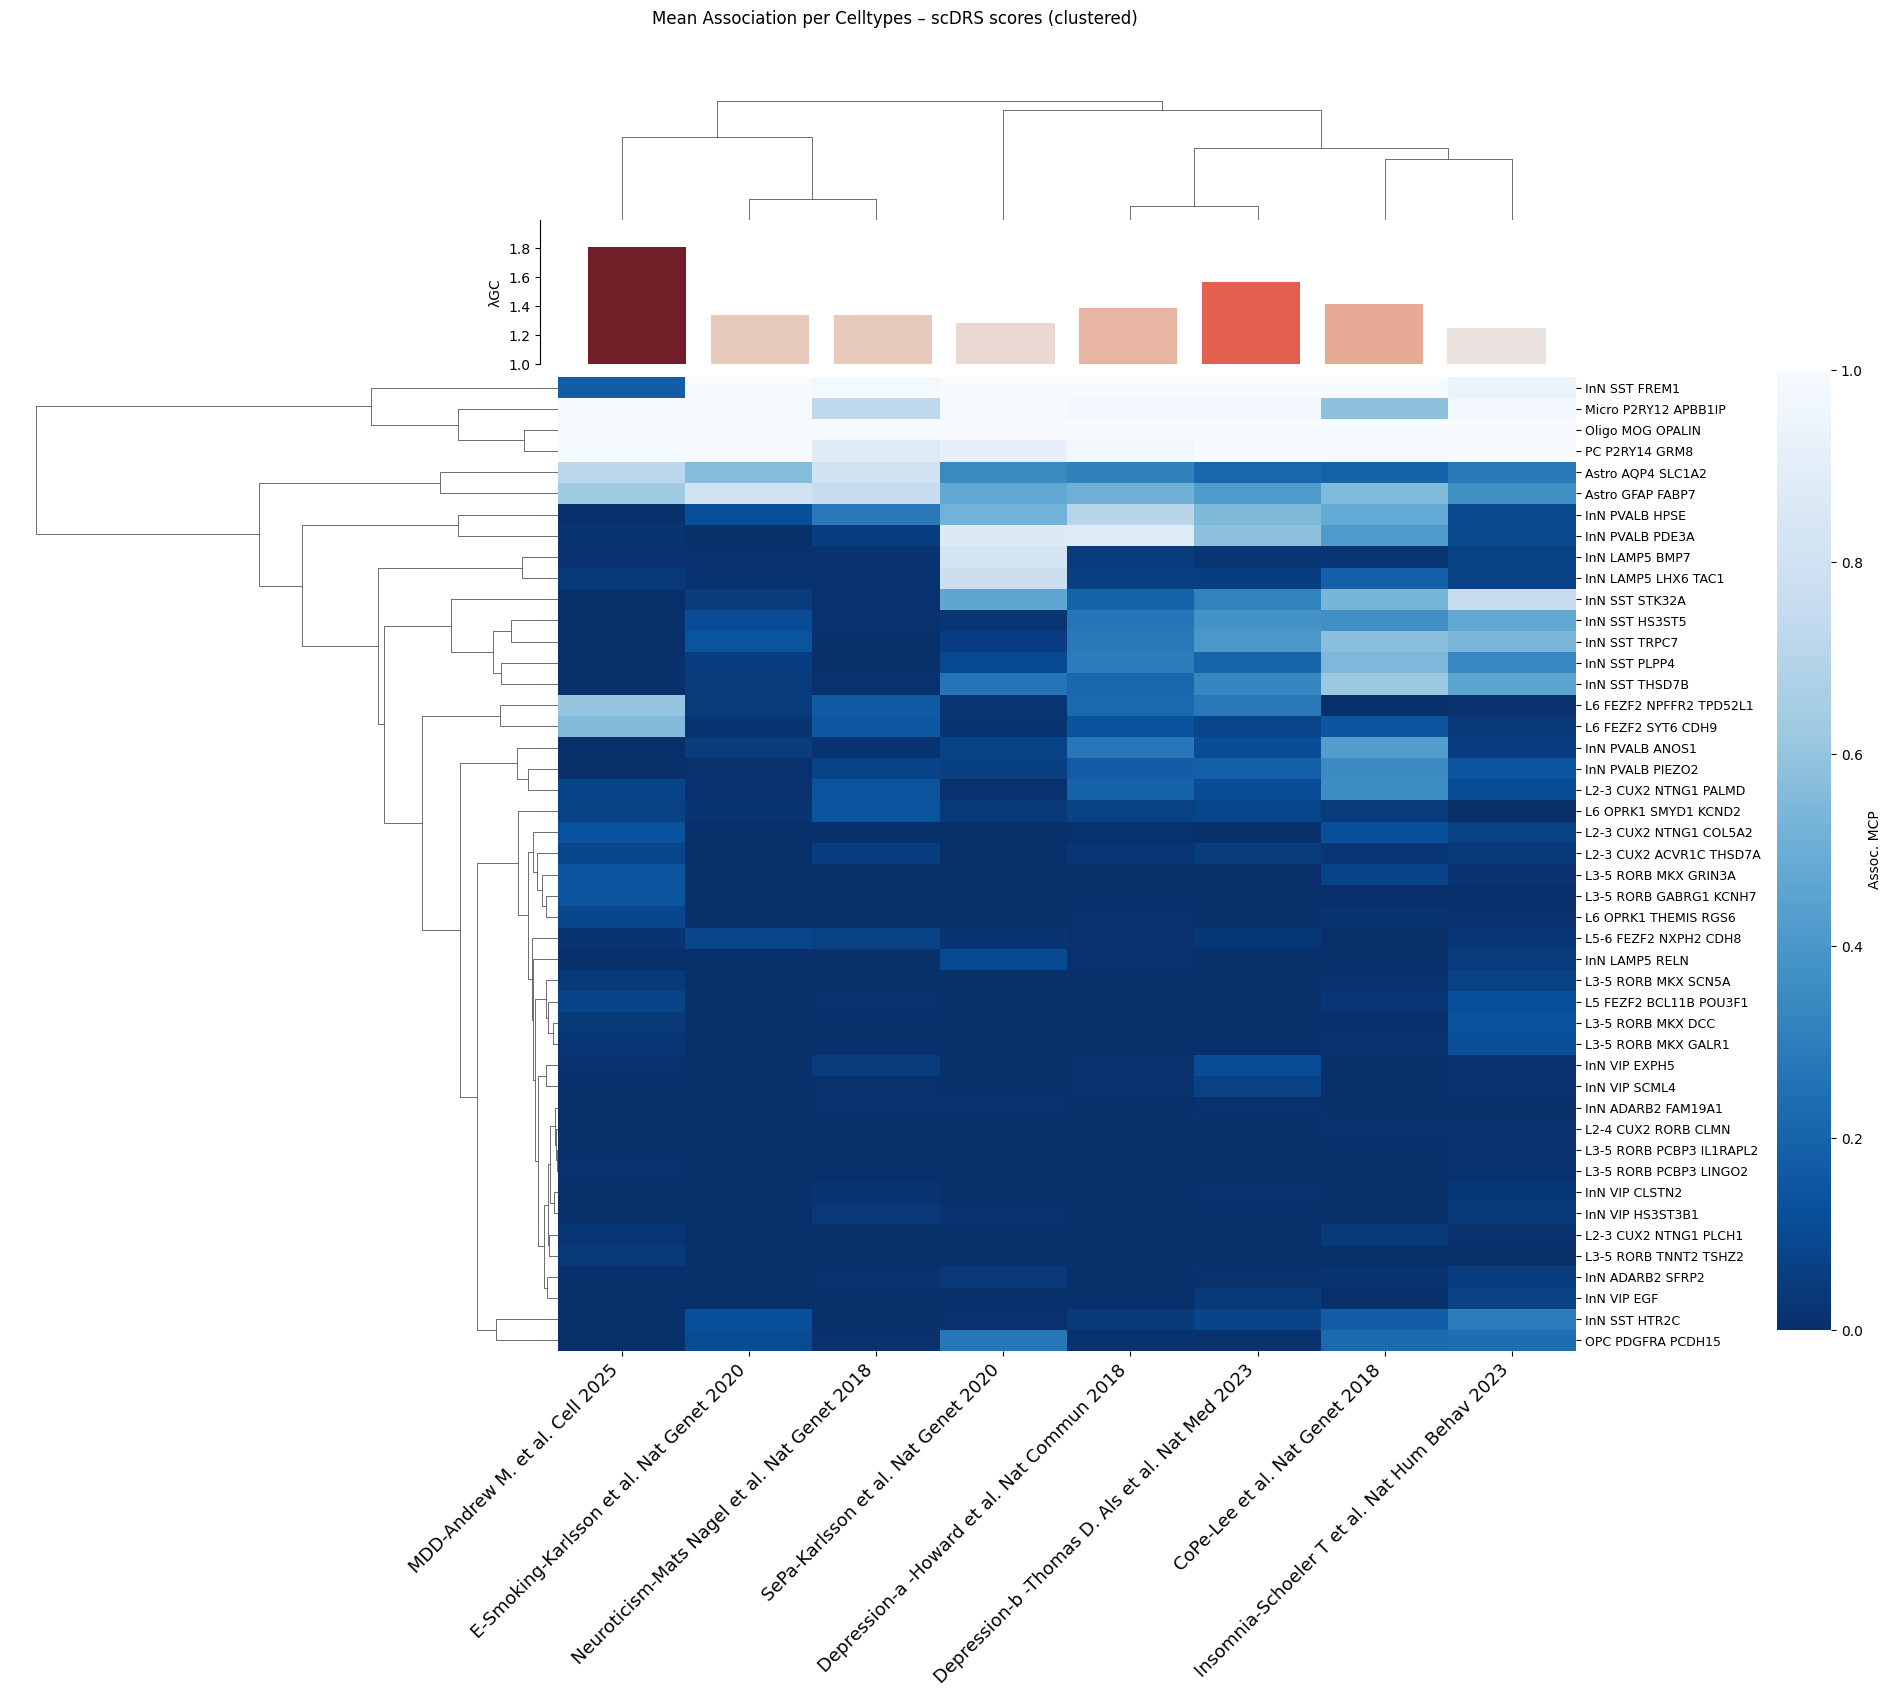

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === 基础参数 ===
traits = ['MDD', 'E-Smoking', 'CoPe', 'Depression', 'Insomnia2', 'Neuroticism', 'Depression3','SePa']
traits_names = [
    'MDD-Andrew M. et al. Cell 2025',
    'E-Smoking-Karlsson et al. Nat Genet 2020',
    'CoPe-Lee et al. Nat Genet 2018',
    'Depression-a -Howard et al. Nat Commun 2018',
    'Insomnia-Schoeler T et al. Nat Hum Behav 2023',
    'Neuroticism-Mats Nagel et al. Nat Genet 2018',
    'Depression-b -Thomas D. Als et al. Nat Med 2023',
    'SePa-Karlsson et al. Nat Genet 2020'
]

# === 读取scDRS结果 ===
dict_df_stats = {
    trait: pd.read_csv(
        f"/biostack/home/suchenyi/graduate/scdrs/downstream_hg38/{trait}.scdrs_group.dominant_labels",
        sep="\t", index_col=0
    )
    for trait in traits
}

samples = list(dict_df_stats[traits[0]].index)
assoc_matrix = np.array([
    dict_df_stats[trait].loc[samples, "assoc_mcp"].values
    for trait in traits
]).T
df_assoc = pd.DataFrame(assoc_matrix, index=samples, columns=traits)

# === 读取λGC文件 ===
df_gc = pd.read_csv("/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv", sep="\t")
name_map = {
    'Depression3': 'Depression3',
    'MDD': 'MDD',
    'SePa': 'SePa',
    'CoPe': 'CoPe',
    'Insomnia2': 'Insomnia2',
    'Neuroticism': 'Neuroticism',
    'E-Smoking': 'E-Smoking',
    'Depression': 'Depression'
}

df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")
lambda_gc_values = []
for t in traits:
    name_in_gc = name_map.get(t, t)
    if name_in_gc in df_gc.index:
        lambda_gc_values.append(df_gc.loc[name_in_gc, "Lambda_GC"])
    else:
        lambda_gc_values.append(np.nan)
lambda_gc_values = np.array(lambda_gc_values, dtype=float)
lambda_gc_values = np.nan_to_num(lambda_gc_values, nan=1.0, posinf=1.0, neginf=1.0)

# === 绘制热图 ===
g = sns.clustermap(
    df_assoc,
    cmap="Blues_r",
    vmin=0, vmax=1,
    figsize=(18, 12),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.35, 0.15),
    cbar_pos=(0.99, 0.05, 0.03, 0.8),
    cbar_kws={"label": "Assoc. MCP", "shrink": 0.5}
)

# 获取聚类顺序
col_order = g.dendrogram_col.reordered_ind
ordered_traits = [df_assoc.columns[i] for i in col_order]
ordered_trait_labels = [traits_names[traits.index(t)] for t in ordered_traits]
ordered_gc = [lambda_gc_values[traits.index(t)] for t in ordered_traits]

# === 调整列聚类树位置，向上腾出空间放柱状图 ===
col_dendro_ax = g.ax_col_dendrogram
pos = col_dendro_ax.get_position()
new_height = pos.height * 0.95  # 缩短 dendrogram 高度
new_y = pos.y0 + pos.height * 0.7  # 上移 dendrogram
col_dendro_ax.set_position([pos.x0, new_y, pos.width, new_height])
# === 绘制顶部 λGC 柱状图 ===
bar_ax = g.fig.add_axes([
    pos.x0-0.01,                # 与 dendrogram 左对齐
    new_y - 0.09,          # 放在 dendrogram 下方、热图上方
    pos.width+0.02,
    0.12                   # 柱状图高度
])
bar_ax.bar(range(len(ordered_traits)), ordered_gc, color="gray", alpha=0.8)
bar_ax.set_xticks(range(len(ordered_traits)))
bar_ax.set_xticklabels([])
bar_ax.set_ylabel("λGC", fontsize=10)
bar_ax.set_ylim(1, np.nanmax(ordered_gc) * 1.1)
bar_ax.spines[["top", "right","bottom"]].set_visible(False)
bar_ax.tick_params(axis='x', which='both', bottom=False)
norm = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors = [cm.Reds(norm(val)) for val in ordered_gc]  # Reds colormap
bar_ax.bar(range(len(ordered_traits)), ordered_gc, color=colors, alpha=0.8, edgecolor="none")


# === 设置热图 x轴标签 ===
heatmap_ax = g.ax_heatmap
heatmap_ax.set_xticklabels(ordered_trait_labels, rotation=45, ha="right", fontsize=13)
heatmap_ax.set_yticklabels(heatmap_ax.get_yticklabels(), fontsize=9)

# 主标题
g.fig.suptitle("Mean Association per Celltypes – scDRS scores (clustered)",
               fontsize=12, y=1.15)

# 保存
g.savefig("traits×celltype_scDRS_MDD_GWAS_Association_Heatmap_with_LambdaGC_v1.pdf", dpi=300)
plt.show()


共读取 90 个 traits
原始 traits 数量: 90
λGC<=2 后剩余: 85


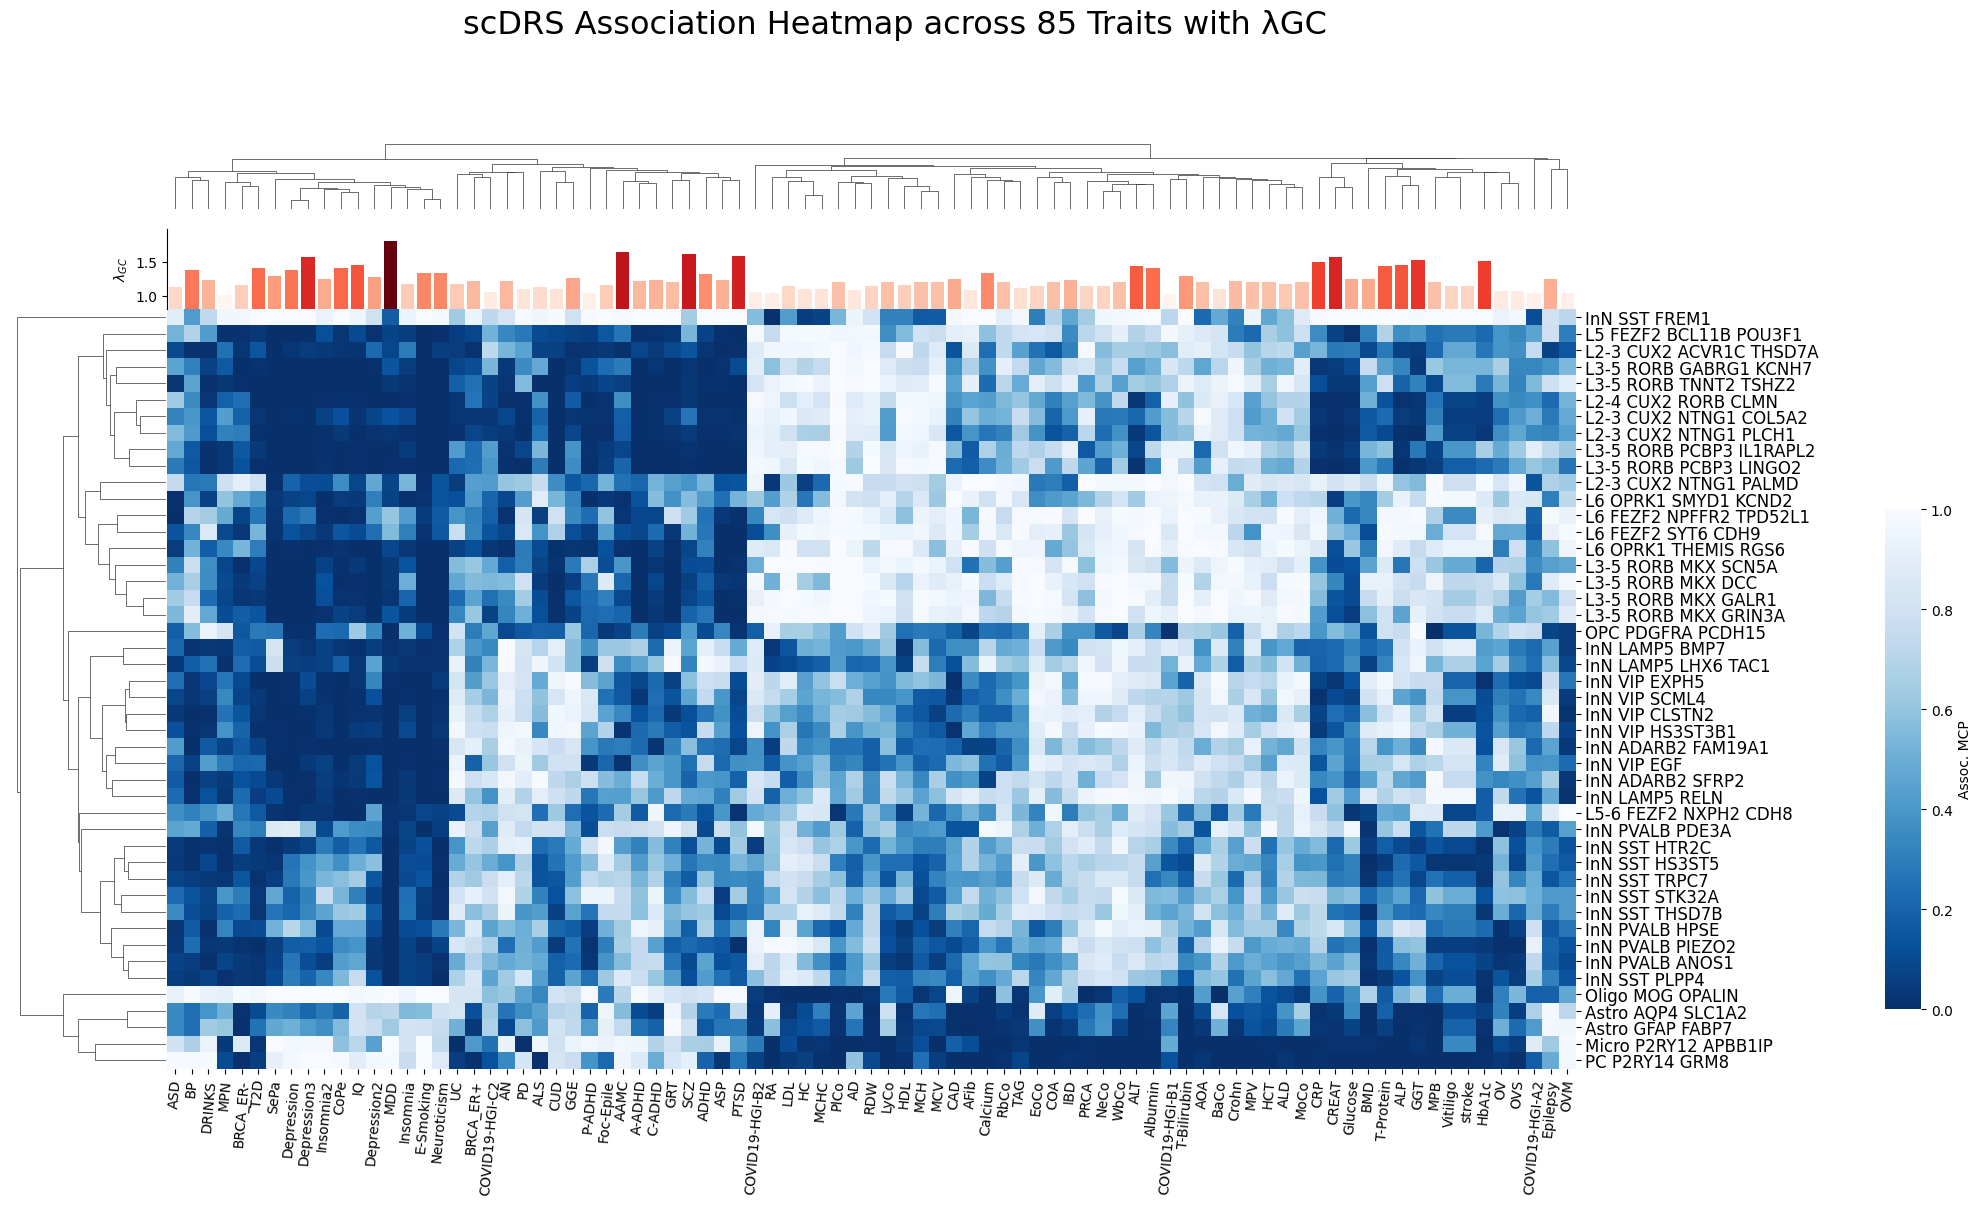

In [9]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ================================
# 1. 自动读取 traits
# ================================
data_dir = "/biostack/home/suchenyi/graduate/scdrs/downstream_hg38"

traits = [
    f.replace(".scdrs_group.dominant_labels", "")
    for f in os.listdir(data_dir)
    if f.endswith(".scdrs_group.dominant_labels")
]

traits = sorted(traits)  # 保证顺序稳定
print(f"共读取 {len(traits)} 个 traits")
# ================================
# 读取 λGC 并筛选 traits
# ================================
gc_file = "/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv"

df_gc = pd.read_csv(gc_file, sep="\t")
df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")

# 过滤 λGC <= 3
valid_traits = df_gc[df_gc["Lambda_GC"] <= 2].index.tolist()

# 与已有 traits 取交集
traits_filtered = [t for t in traits if t in valid_traits]

print(f"原始 traits 数量: {len(traits)}")
print(f"λGC<=2 后剩余: {len(traits_filtered)}")

# ================================
# 2. 读取 scDRS 结果
# ================================
dict_df_stats = {
    trait: pd.read_csv(
        os.path.join(data_dir, f"{trait}.scdrs_group.dominant_labels"),
        sep="\t", index_col=0
    )
    for trait in traits_filtered
}

# 使用第一个 trait 的 celltype 作为索引
samples = list(dict_df_stats[traits_filtered[0]].index)

assoc_matrix = np.array([
    dict_df_stats[trait].loc[samples, "assoc_mcp"].values
    for trait in traits_filtered
]).T

df_assoc = pd.DataFrame(assoc_matrix, index=samples, columns=traits_filtered)

# ================================
# 3. 读取 λGC
# ================================
gc_file = "/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv"

df_gc = pd.read_csv(gc_file, sep="\t")
df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")

lambda_gc_values = []
for t in traits_filtered:
    if t in df_gc.index:
        lambda_gc_values.append(df_gc.loc[t, "Lambda_GC"])
    else:
        lambda_gc_values.append(np.nan)

lambda_gc_values = np.array(lambda_gc_values, dtype=float)

# 处理异常值
lambda_gc_values = np.nan_to_num(lambda_gc_values, nan=1.0, posinf=1.0, neginf=1.0)

# ================================
# 4. 画 clustermap
# ================================
g = sns.clustermap(
    df_assoc,
    cmap="Blues_r",
    vmin=0, vmax=1,
    figsize=(18, 10), 
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=(1.05, 0.2, 0.02, 0.5),
    cbar_kws={"label": "Assoc. MCP"}
)

# ================================
# 5. 获取聚类顺序
# ================================
col_order = g.dendrogram_col.reordered_ind
ordered_traits = [df_assoc.columns[i] for i in col_order]
ordered_gc = [lambda_gc_values[traits_filtered.index(t)] for t in ordered_traits]

# ================================
# 6. 调整 dendrogram
# ================================
col_dendro_ax = g.ax_col_dendrogram
pos = col_dendro_ax.get_position()

col_dendro_ax.set_position([
    pos.x0,
    pos.y0 + 0.1,
    pos.width,
    pos.height * 0.8
])

# ================================
# 7. λGC barplot
# ================================
bar_ax = g.fig.add_axes([
    pos.x0,
    pos.y0, 
    pos.width,
    0.08
])

# 确保 x 轴范围与热图完全一致
bar_ax.set_xlim(g.ax_heatmap.get_xlim())

# 绘图：x 坐标应为 np.arange(len) + 0.5 来居中对齐
x_pos = np.arange(len(ordered_traits)) + 0.5
norm = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors = [cm.Reds(norm(val)) for val in ordered_gc]

bar_ax.bar(x_pos, ordered_gc, color=colors, width=0.8, align='center')

# 移除刻度，仅保留 y 轴标签
bar_ax.set_xticks([])
bar_ax.set_ylabel("$\lambda_{GC}$", fontsize=10)

# 动态调整 Y 轴范围
y_min = min(ordered_gc) * 0.8
bar_ax.set_ylim(y_min, max(ordered_gc) * 1.1)

bar_ax.spines[["top", "right", "bottom"]].set_visible(False)
# ================================
# 8. 标签优化
# ================================
heatmap_ax = g.ax_heatmap

heatmap_ax.set_xticklabels(
    ordered_traits,
    rotation=85,  
    fontsize=10
)

heatmap_ax.set_yticklabels(
    heatmap_ax.get_yticklabels(),
    fontsize=12
)

# ================================
# 9. 标题 & 保存
# ================================
g.fig.suptitle(
    "scDRS Association Heatmap across 85 Traits with λGC",
    fontsize=23,
    y=1.2
)

plt.savefig(
    "traits_90_scDRS_lambdaGC_heatmap_MCP_λGC<2_dominant_labels.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "traits_90_scDRS_lambdaGC_heatmap_MCP_λGC<2_dominant_labels.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


<>:141: SyntaxWarning: invalid escape sequence '\l'
<>:141: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_79555/559815150.py:141: SyntaxWarning: invalid escape sequence '\l'
  bar_ax.set_ylabel("$\lambda_{GC}$", fontsize=10)


共读取 90 个 traits
原始 traits 数量: 90
λGC<=3 后剩余: 87


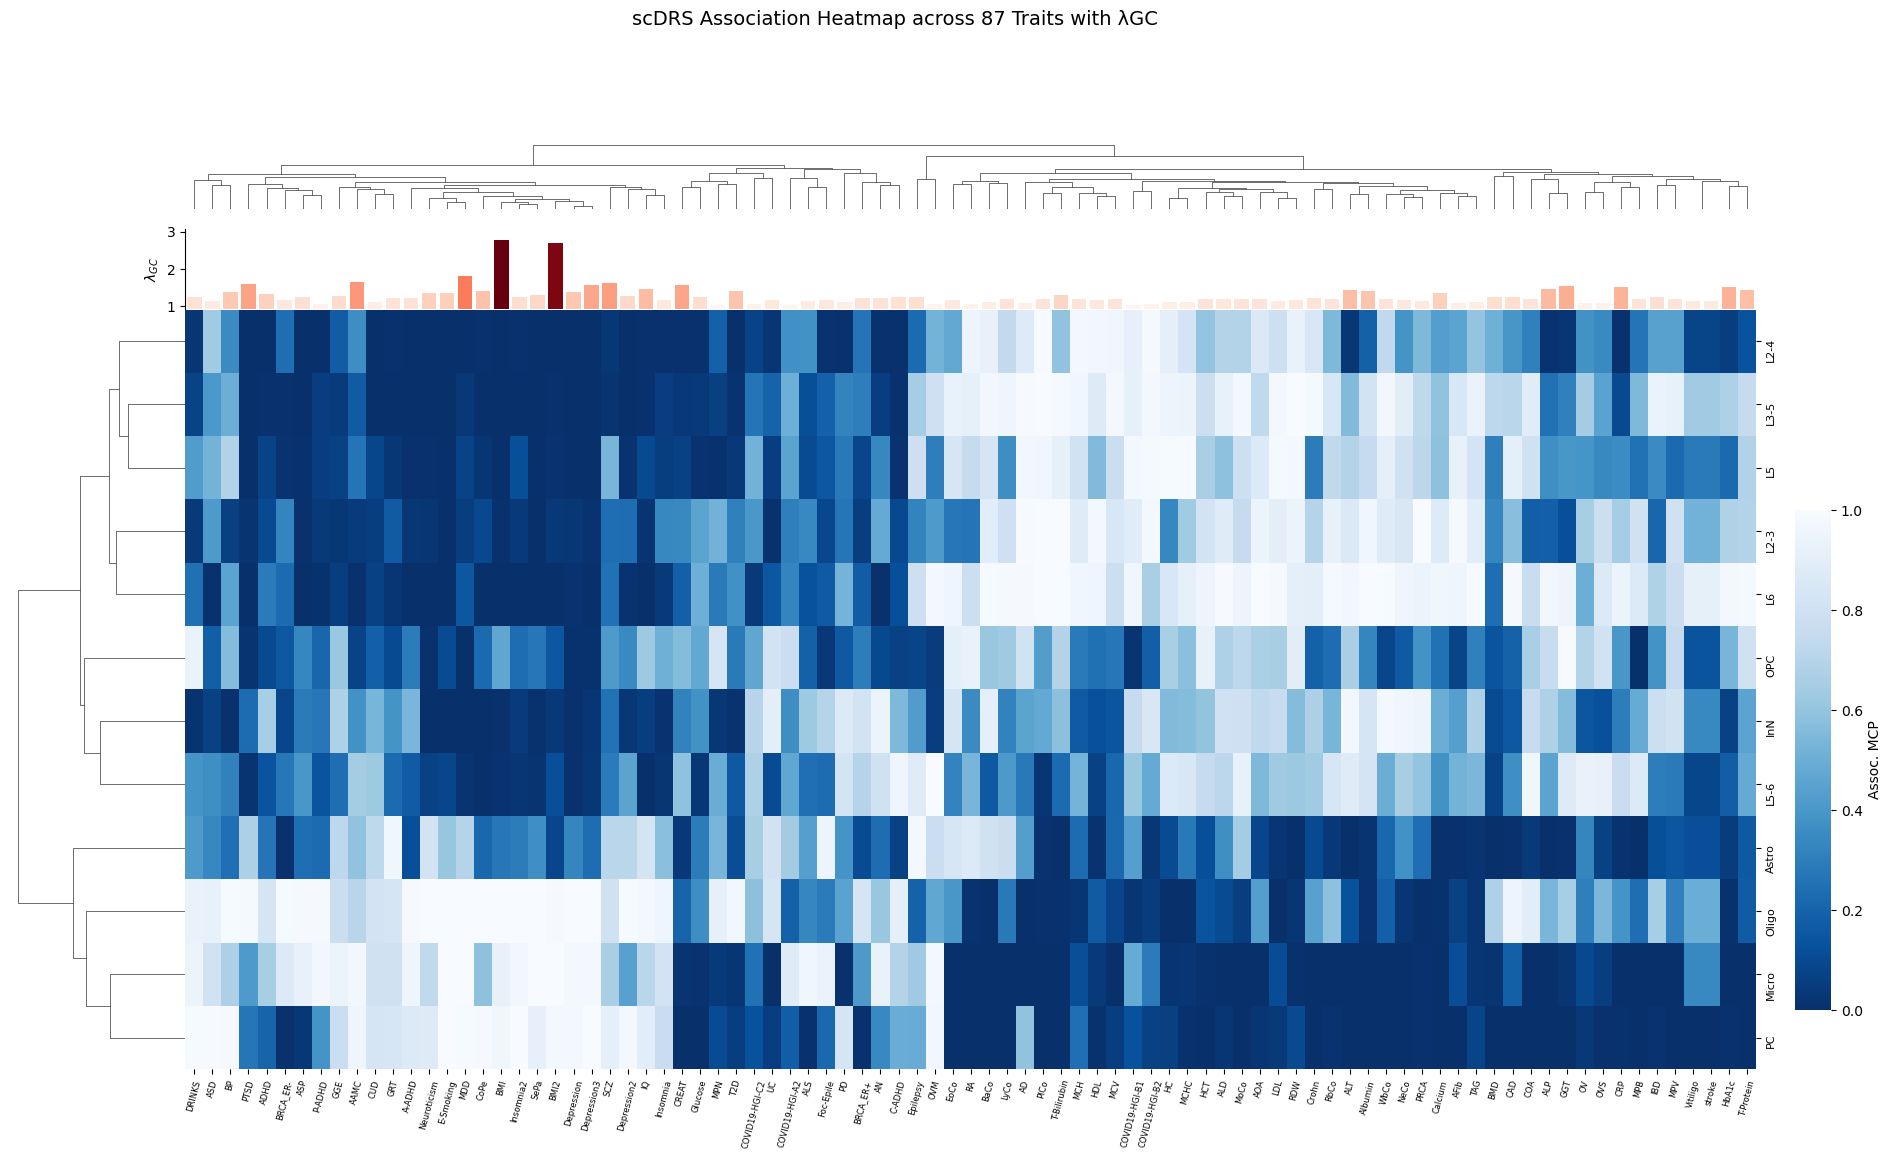

In [37]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ================================
# 1. 自动读取 traits
# ================================
data_dir = "/biostack/home/suchenyi/graduate/scdrs/downstream_hg38"

traits = [
    f.replace(".scdrs_group.dominant_labels_short", "")
    for f in os.listdir(data_dir)
    if f.endswith(".scdrs_group.dominant_labels_short")
]

traits = sorted(traits)  # 保证顺序稳定
print(f"共读取 {len(traits)} 个 traits")
# ================================
# 读取 λGC 并筛选 traits
# ================================
gc_file = "/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv"

df_gc = pd.read_csv(gc_file, sep="\t")
df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")

# 过滤 λGC <= 3
valid_traits = df_gc[df_gc["Lambda_GC"] <= 3].index.tolist()

# 与已有 traits 取交集
traits_filtered = [t for t in traits if t in valid_traits]

print(f"原始 traits 数量: {len(traits)}")
print(f"λGC<=3 后剩余: {len(traits_filtered)}")

# ================================
# 2. 读取 scDRS 结果
# ================================
dict_df_stats = {
    trait: pd.read_csv(
        os.path.join(data_dir, f"{trait}.scdrs_group.dominant_labels_short"),
        sep="\t", index_col=0
    )
    for trait in traits_filtered
}

# 使用第一个 trait 的 celltype 作为索引
samples = list(dict_df_stats[traits_filtered[0]].index)

assoc_matrix = np.array([
    dict_df_stats[trait].loc[samples, "assoc_mcp"].values
    for trait in traits_filtered
]).T

df_assoc = pd.DataFrame(assoc_matrix, index=samples, columns=traits_filtered)

# ================================
# 3. 读取 λGC
# ================================
gc_file = "/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv"

df_gc = pd.read_csv(gc_file, sep="\t")
df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")

lambda_gc_values = []
for t in traits_filtered:
    if t in df_gc.index:
        lambda_gc_values.append(df_gc.loc[t, "Lambda_GC"])
    else:
        lambda_gc_values.append(np.nan)

lambda_gc_values = np.array(lambda_gc_values, dtype=float)

# 处理异常值
lambda_gc_values = np.nan_to_num(lambda_gc_values, nan=1.0, posinf=1.0, neginf=1.0)

# ================================
# 4. 画 clustermap
# ================================
g = sns.clustermap(
    df_assoc,
    cmap="Blues_r",
    vmin=0, vmax=1,
    figsize=(18, 10), 
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=(1.0, 0.2, 0.02, 0.5),
    cbar_kws={"label": "Assoc. MCP"}
)

# ================================
# 5. 获取聚类顺序
# ================================
col_order = g.dendrogram_col.reordered_ind
ordered_traits = [df_assoc.columns[i] for i in col_order]
ordered_gc = [lambda_gc_values[traits_filtered.index(t)] for t in ordered_traits]

# ================================
# 6. 调整 dendrogram
# ================================
col_dendro_ax = g.ax_col_dendrogram
pos = col_dendro_ax.get_position()

col_dendro_ax.set_position([
    pos.x0,
    pos.y0 + 0.1,
    pos.width,
    pos.height * 0.8
])

# ================================
# 7. λGC barplot
# ================================
bar_ax = g.fig.add_axes([
    pos.x0,
    pos.y0, 
    pos.width,
    0.08
])

# 确保 x 轴范围与热图完全一致
bar_ax.set_xlim(g.ax_heatmap.get_xlim())

# 绘图：x 坐标应为 np.arange(len) + 0.5 来居中对齐
x_pos = np.arange(len(ordered_traits)) + 0.5
norm = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors = [cm.Reds(norm(val)) for val in ordered_gc]

bar_ax.bar(x_pos, ordered_gc, color=colors, width=0.8, align='center')

# 移除刻度，仅保留 y 轴标签
bar_ax.set_xticks([])
bar_ax.set_ylabel("$\lambda_{GC}$", fontsize=10)

# 动态调整 Y 轴范围
y_min = min(ordered_gc) * 0.9
bar_ax.set_ylim(y_min, max(ordered_gc) * 1.1)

bar_ax.spines[["top", "right", "bottom"]].set_visible(False)
# ================================
# 8. 标签优化
# ================================
heatmap_ax = g.ax_heatmap

heatmap_ax.set_xticklabels(
    ordered_traits,
    rotation=75,  
    fontsize=6
)

heatmap_ax.set_yticklabels(
    heatmap_ax.get_yticklabels(),
    fontsize=8
)

# ================================
# 9. 标题 & 保存
# ================================
g.fig.suptitle(
    "scDRS Association Heatmap across 87 Traits with λGC",
    fontsize=14,
    y=1.2
)

plt.savefig(
    "traits_90_scDRS_lambdaGC_heatmap_λGC<2_dominant_labels_Short.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "traits_90_scDRS_lambdaGC_heatmap_λGC<2_dominant_labels_Short.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


共读取 90 个 traits
原始 traits 数量: 90
λGC<=3 后剩余: 87


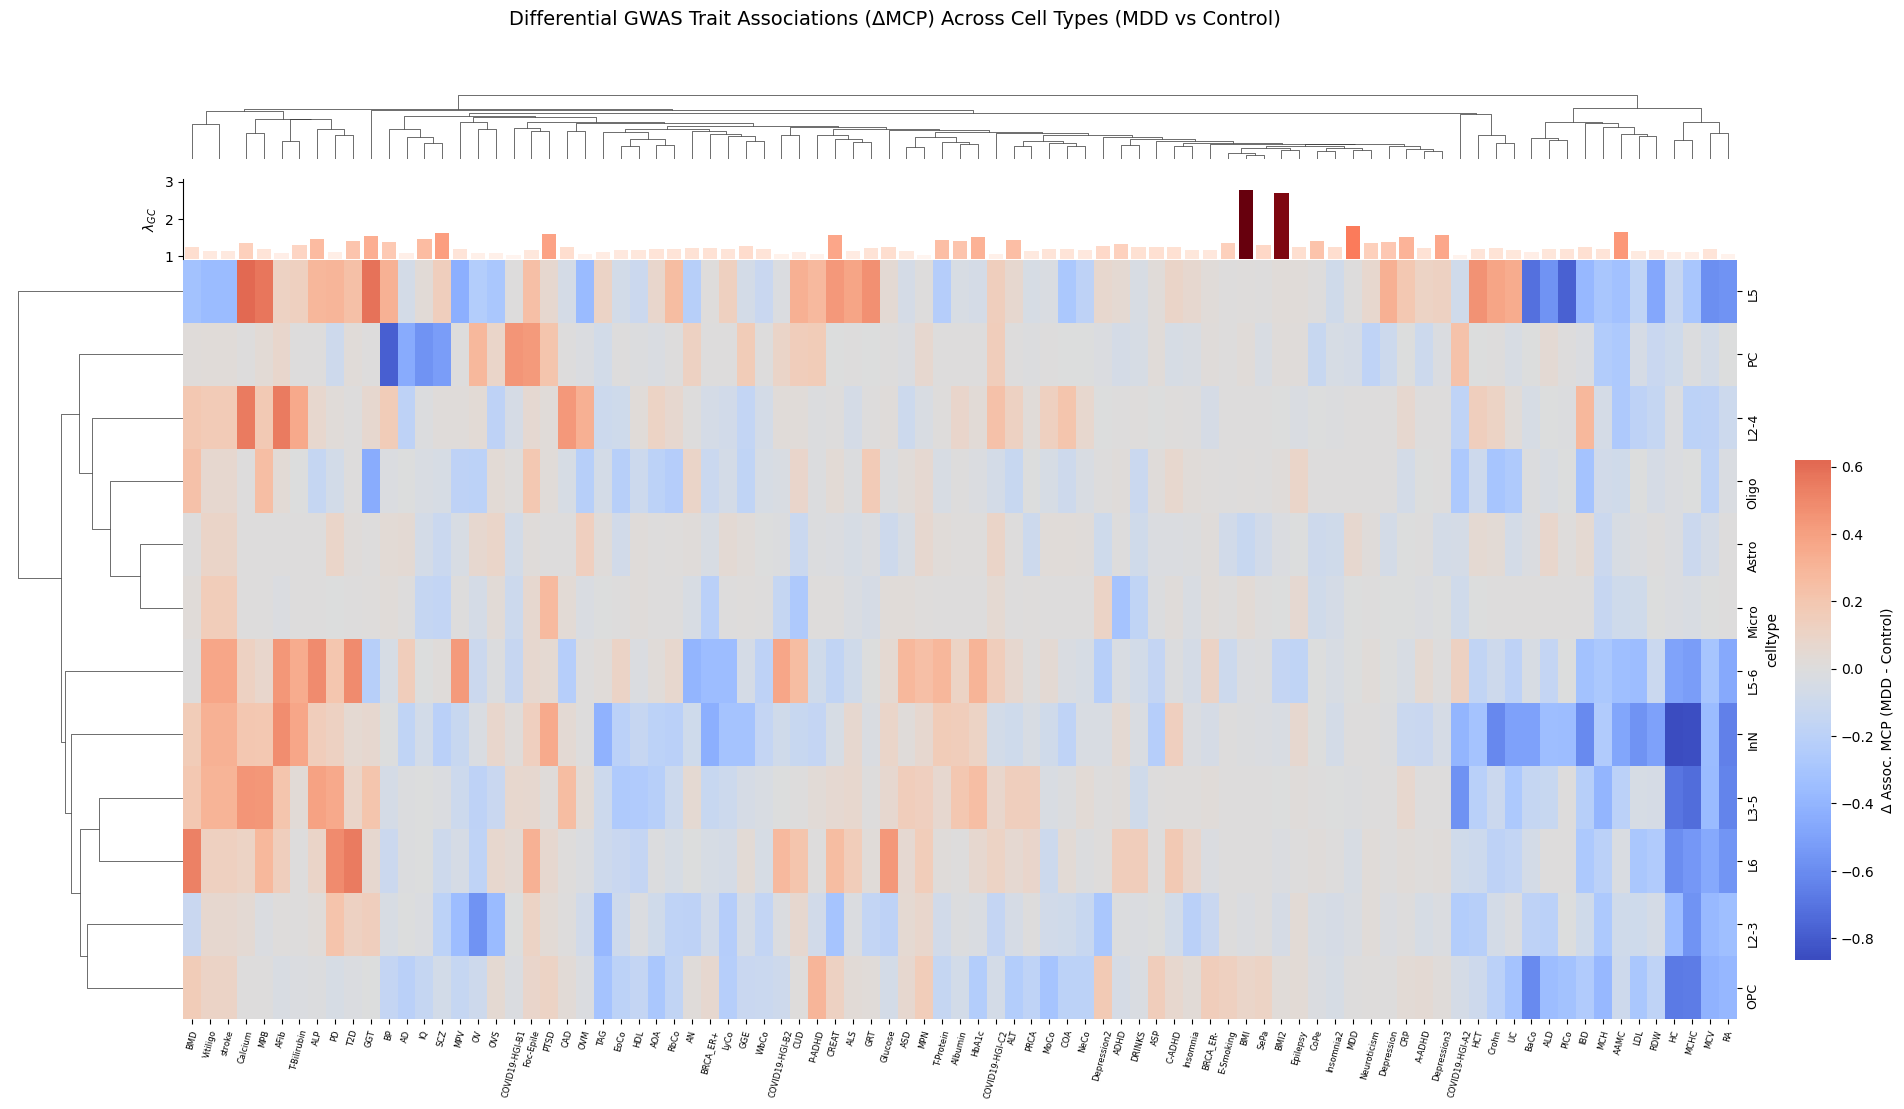

In [29]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ================================
# 1. 路径设置
# ================================
data_dir = "/biostack/home/suchenyi/graduate/scdrs/downstream_hg38"
gc_file = "/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv"

# ================================
# 2. 自动读取 traits
# ================================
traits = [
    f.replace(".scdrs_group.con_ct", "")
    for f in os.listdir(data_dir)
    if f.endswith(".scdrs_group.con_ct")
]

traits = sorted(traits)
print(f"共读取 {len(traits)} 个 traits")

# ================================
# 3. 读取 λGC 并筛选 traits
# ================================
df_gc = pd.read_csv(gc_file, sep="\t")
df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")

valid_traits = df_gc[df_gc["Lambda_GC"] <= 3].index.tolist()
traits_filtered = [t for t in traits if t in valid_traits]

print(f"原始 traits 数量: {len(traits)}")
print(f"λGC<=3 后剩余: {len(traits_filtered)}")

# ================================
# 4. 计算 ΔMCP
# ================================
dict_delta = {}

for trait in traits_filtered:
    file_path = os.path.join(data_dir, f"{trait}.scdrs_group.con_ct")
    
    if not os.path.exists(file_path):
        continue
    
    df = pd.read_csv(file_path, sep="\t")
    
    # 拆分 group → condition + celltype
    df[["condition", "celltype"]] = df["group"].str.split("&", expand=True)
    
    # pivot
    df_wide = df.pivot(index="celltype", columns="condition", values="assoc_mcp")
    
    # 检查是否有 C 和 S
    if not {"C", "S"}.issubset(df_wide.columns):
        continue
    
    # 计算 ΔMCP
    df_wide["delta"] = df_wide["S"] - df_wide["C"]
    
    dict_delta[trait] = df_wide["delta"]

# 合并为矩阵
df_delta = pd.DataFrame(dict_delta)

# 行排序（保证一致）
df_delta = df_delta.sort_index()

# ================================
# 5. 处理 λGC 顺序
# ================================
lambda_gc_values = []
for t in df_delta.columns:
    if t in df_gc.index:
        lambda_gc_values.append(df_gc.loc[t, "Lambda_GC"])
    else:
        lambda_gc_values.append(np.nan)

lambda_gc_values = np.array(lambda_gc_values, dtype=float)
lambda_gc_values = np.nan_to_num(lambda_gc_values, nan=1.0, posinf=1.0, neginf=1.0)

# ================================
# 6. 画 clustermap（ΔMCP）
# ================================
g = sns.clustermap(
    df_delta,
    cmap="coolwarm",
    center=0, 
    figsize=(18, 10),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=(1.0, 0.2, 0.02, 0.5),
    cbar_kws={"label": "Δ Assoc. MCP (MDD - Control)"}
)

# ================================
# 7. 获取聚类顺序
# ================================
col_order = g.dendrogram_col.reordered_ind
ordered_traits = [df_delta.columns[i] for i in col_order]
ordered_gc = [df_gc.loc[t, "Lambda_GC"] if t in df_gc.index else 1.0 for t in ordered_traits]

# ================================
# 8. 调整 dendrogram 位置
# ================================
col_dendro_ax = g.ax_col_dendrogram
pos = col_dendro_ax.get_position()

col_dendro_ax.set_position([
    pos.x0,
    pos.y0 + 0.1,
    pos.width,
    pos.height * 0.8
])

# ================================
# 9. λGC barplot
# ================================
bar_ax = g.fig.add_axes([
    pos.x0,
    pos.y0,
    pos.width,
    0.08
])

bar_ax.set_xlim(g.ax_heatmap.get_xlim())

x_pos = np.arange(len(ordered_traits)) + 0.5

norm = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors = [cm.Reds(norm(val)) for val in ordered_gc]

bar_ax.bar(x_pos, ordered_gc, color=colors, width=0.8, align='center')

bar_ax.set_xticks([])
bar_ax.set_ylabel("$\\lambda_{GC}$", fontsize=10)

y_min = min(ordered_gc) * 0.9
bar_ax.set_ylim(y_min, max(ordered_gc) * 1.1)

bar_ax.spines[["top", "right", "bottom"]].set_visible(False)

# ================================
# 10. 标签优化
# ================================
heatmap_ax = g.ax_heatmap

heatmap_ax.set_xticklabels(
    ordered_traits,
    rotation=75,
    fontsize=6
)

heatmap_ax.set_yticklabels(
    heatmap_ax.get_yticklabels(),
    fontsize=9
)

# ================================
# 11. 标题 & 保存
# ================================
g.fig.suptitle(
    "Differential GWAS Trait Associations (ΔMCP) Across Cell Types (MDD vs Control)",
    fontsize=14,
    y=1.15
)

plt.savefig(
    "scDRS_deltaMCP_conCT_lambdaGC_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "scDRS_deltaMCP_conCT_lambdaGC_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

共读取 90 个 traits
原始 traits 数量: 90
λGC<=3 后剩余: 87


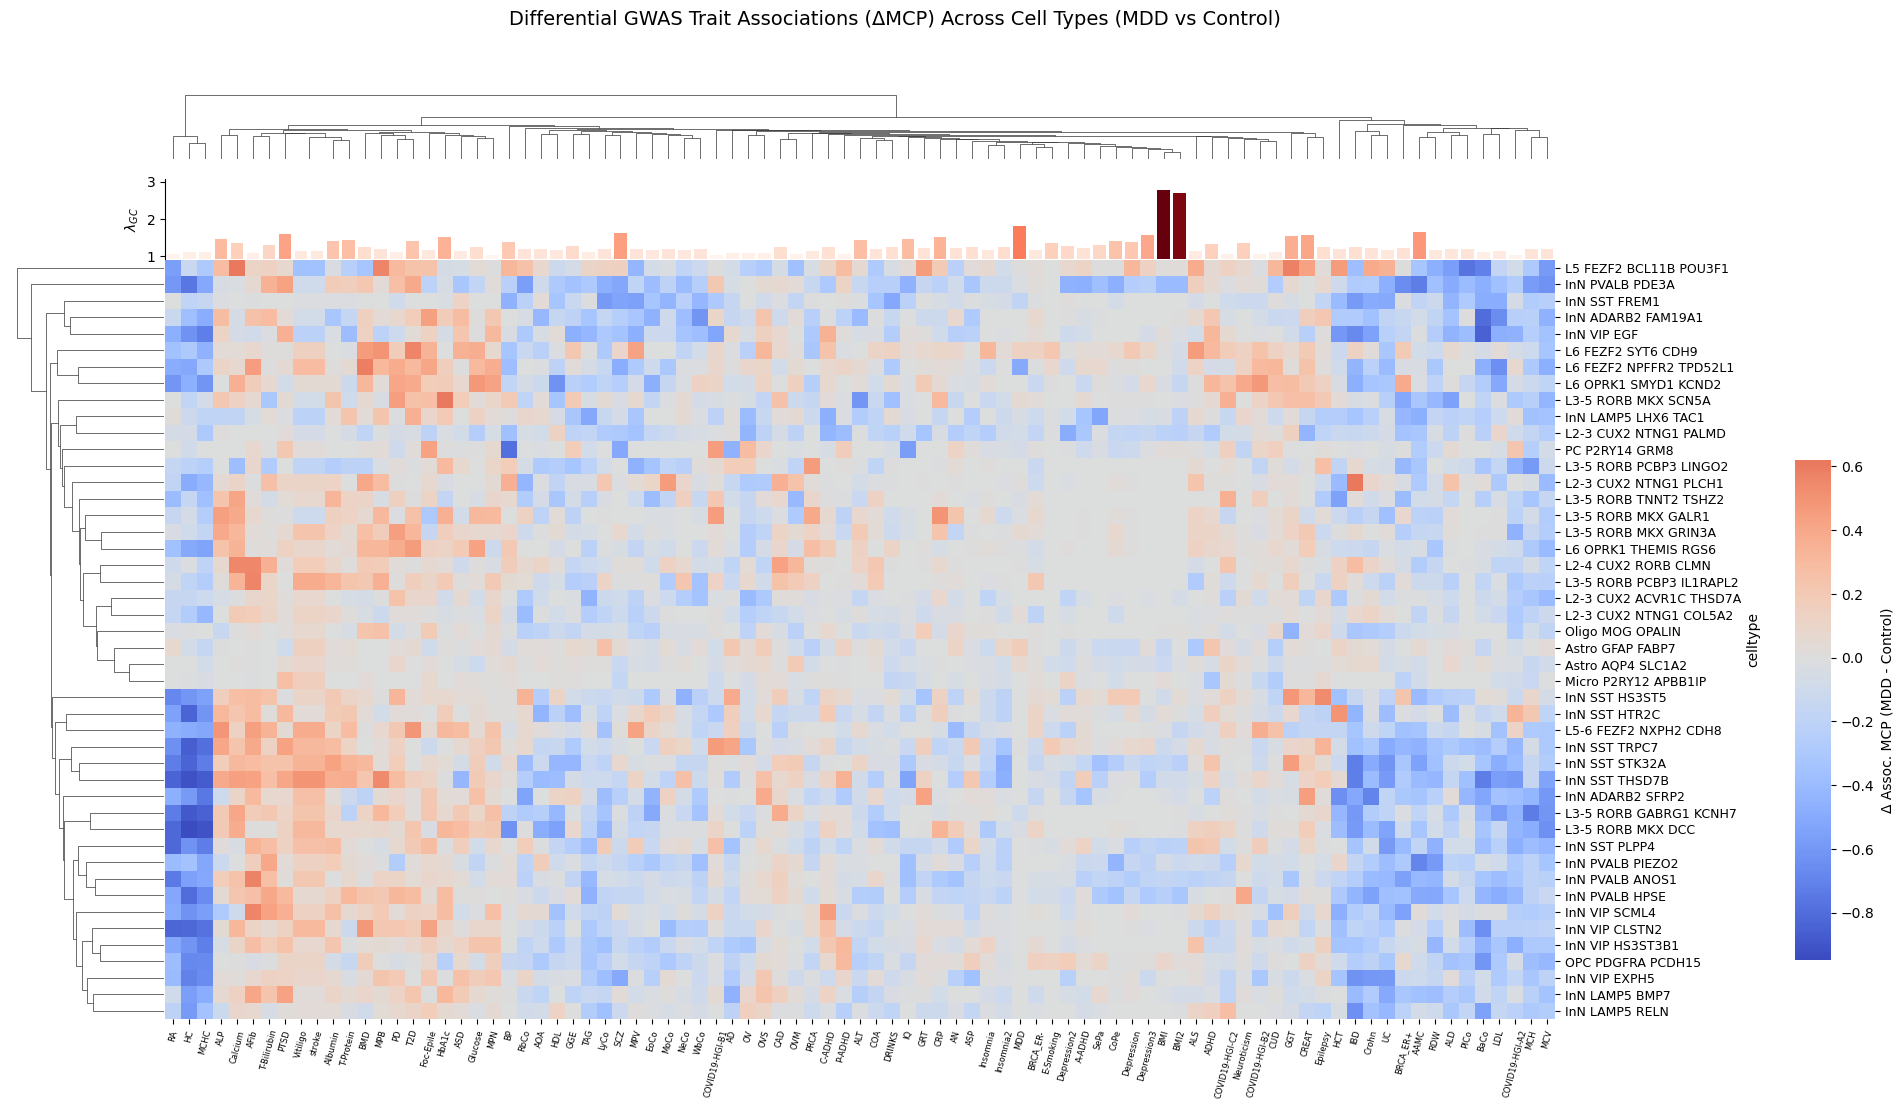

In [30]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ================================
# 1. 路径设置
# ================================
data_dir = "/biostack/home/suchenyi/graduate/scdrs/downstream_hg38"
gc_file = "/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv"

# ================================
# 2. 自动读取 traits
# ================================
traits = [
    f.replace(".scdrs_group.con_cts", "")
    for f in os.listdir(data_dir)
    if f.endswith(".scdrs_group.con_cts")
]

traits = sorted(traits)
print(f"共读取 {len(traits)} 个 traits")

# ================================
# 3. 读取 λGC 并筛选 traits
# ================================
df_gc = pd.read_csv(gc_file, sep="\t")
df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")

valid_traits = df_gc[df_gc["Lambda_GC"] <= 3].index.tolist()
traits_filtered = [t for t in traits if t in valid_traits]

print(f"原始 traits 数量: {len(traits)}")
print(f"λGC<=3 后剩余: {len(traits_filtered)}")

# ================================
# 4. 计算 ΔMCP
# ================================
dict_delta = {}

for trait in traits_filtered:
    file_path = os.path.join(data_dir, f"{trait}.scdrs_group.con_cts")
    
    if not os.path.exists(file_path):
        continue
    
    df = pd.read_csv(file_path, sep="\t")
    
    # 拆分 group → condition + celltype
    df[["condition", "celltype"]] = df["group"].str.split("&", expand=True)
    
    # pivot
    df_wide = df.pivot(index="celltype", columns="condition", values="assoc_mcp")
    
    # 检查是否有 C 和 S
    if not {"C", "S"}.issubset(df_wide.columns):
        continue
    
    # 计算 ΔMCP
    df_wide["delta"] = df_wide["S"] - df_wide["C"]
    
    dict_delta[trait] = df_wide["delta"]

# 合并为矩阵
df_delta = pd.DataFrame(dict_delta)

# 行排序（保证一致）
df_delta = df_delta.sort_index()

# ================================
# 5. 处理 λGC 顺序
# ================================
lambda_gc_values = []
for t in df_delta.columns:
    if t in df_gc.index:
        lambda_gc_values.append(df_gc.loc[t, "Lambda_GC"])
    else:
        lambda_gc_values.append(np.nan)

lambda_gc_values = np.array(lambda_gc_values, dtype=float)
lambda_gc_values = np.nan_to_num(lambda_gc_values, nan=1.0, posinf=1.0, neginf=1.0)

# ================================
# 6. 画 clustermap（ΔMCP）
# ================================
g = sns.clustermap(
    df_delta,
    cmap="coolwarm",
    center=0, 
    figsize=(18, 10),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=(1.0, 0.2, 0.02, 0.5),
    cbar_kws={"label": "Δ Assoc. MCP (MDD - Control)"}
)

# ================================
# 7. 获取聚类顺序
# ================================
col_order = g.dendrogram_col.reordered_ind
ordered_traits = [df_delta.columns[i] for i in col_order]
ordered_gc = [df_gc.loc[t, "Lambda_GC"] if t in df_gc.index else 1.0 for t in ordered_traits]

# ================================
# 8. 调整 dendrogram 位置
# ================================
col_dendro_ax = g.ax_col_dendrogram
pos = col_dendro_ax.get_position()

col_dendro_ax.set_position([
    pos.x0,
    pos.y0 + 0.1,
    pos.width,
    pos.height * 0.8
])

# ================================
# 9. λGC barplot
# ================================
bar_ax = g.fig.add_axes([
    pos.x0,
    pos.y0,
    pos.width,
    0.08
])

bar_ax.set_xlim(g.ax_heatmap.get_xlim())

x_pos = np.arange(len(ordered_traits)) + 0.5

norm = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors = [cm.Reds(norm(val)) for val in ordered_gc]

bar_ax.bar(x_pos, ordered_gc, color=colors, width=0.8, align='center')

bar_ax.set_xticks([])
bar_ax.set_ylabel("$\\lambda_{GC}$", fontsize=10)

y_min = min(ordered_gc) * 0.9
bar_ax.set_ylim(y_min, max(ordered_gc) * 1.1)

bar_ax.spines[["top", "right", "bottom"]].set_visible(False)

# ================================
# 10. 标签优化
# ================================
heatmap_ax = g.ax_heatmap

heatmap_ax.set_xticklabels(
    ordered_traits,
    rotation=75,
    fontsize=6
)

heatmap_ax.set_yticklabels(
    heatmap_ax.get_yticklabels(),
    fontsize=9
)

# ================================
# 11. 标题 & 保存
# ================================
g.fig.suptitle(
    "Differential GWAS Trait Associations (ΔMCP) Across Cell Types (MDD vs Control)",
    fontsize=14,
    y=1.15
)

plt.savefig(
    "scDRS_deltaMCP_conCTs_lambdaGC_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "scDRS_deltaMCP_conCTs_lambdaGC_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

共读取 90 个 traits
原始 traits 数量: 90
λGC<=2 后剩余: 85


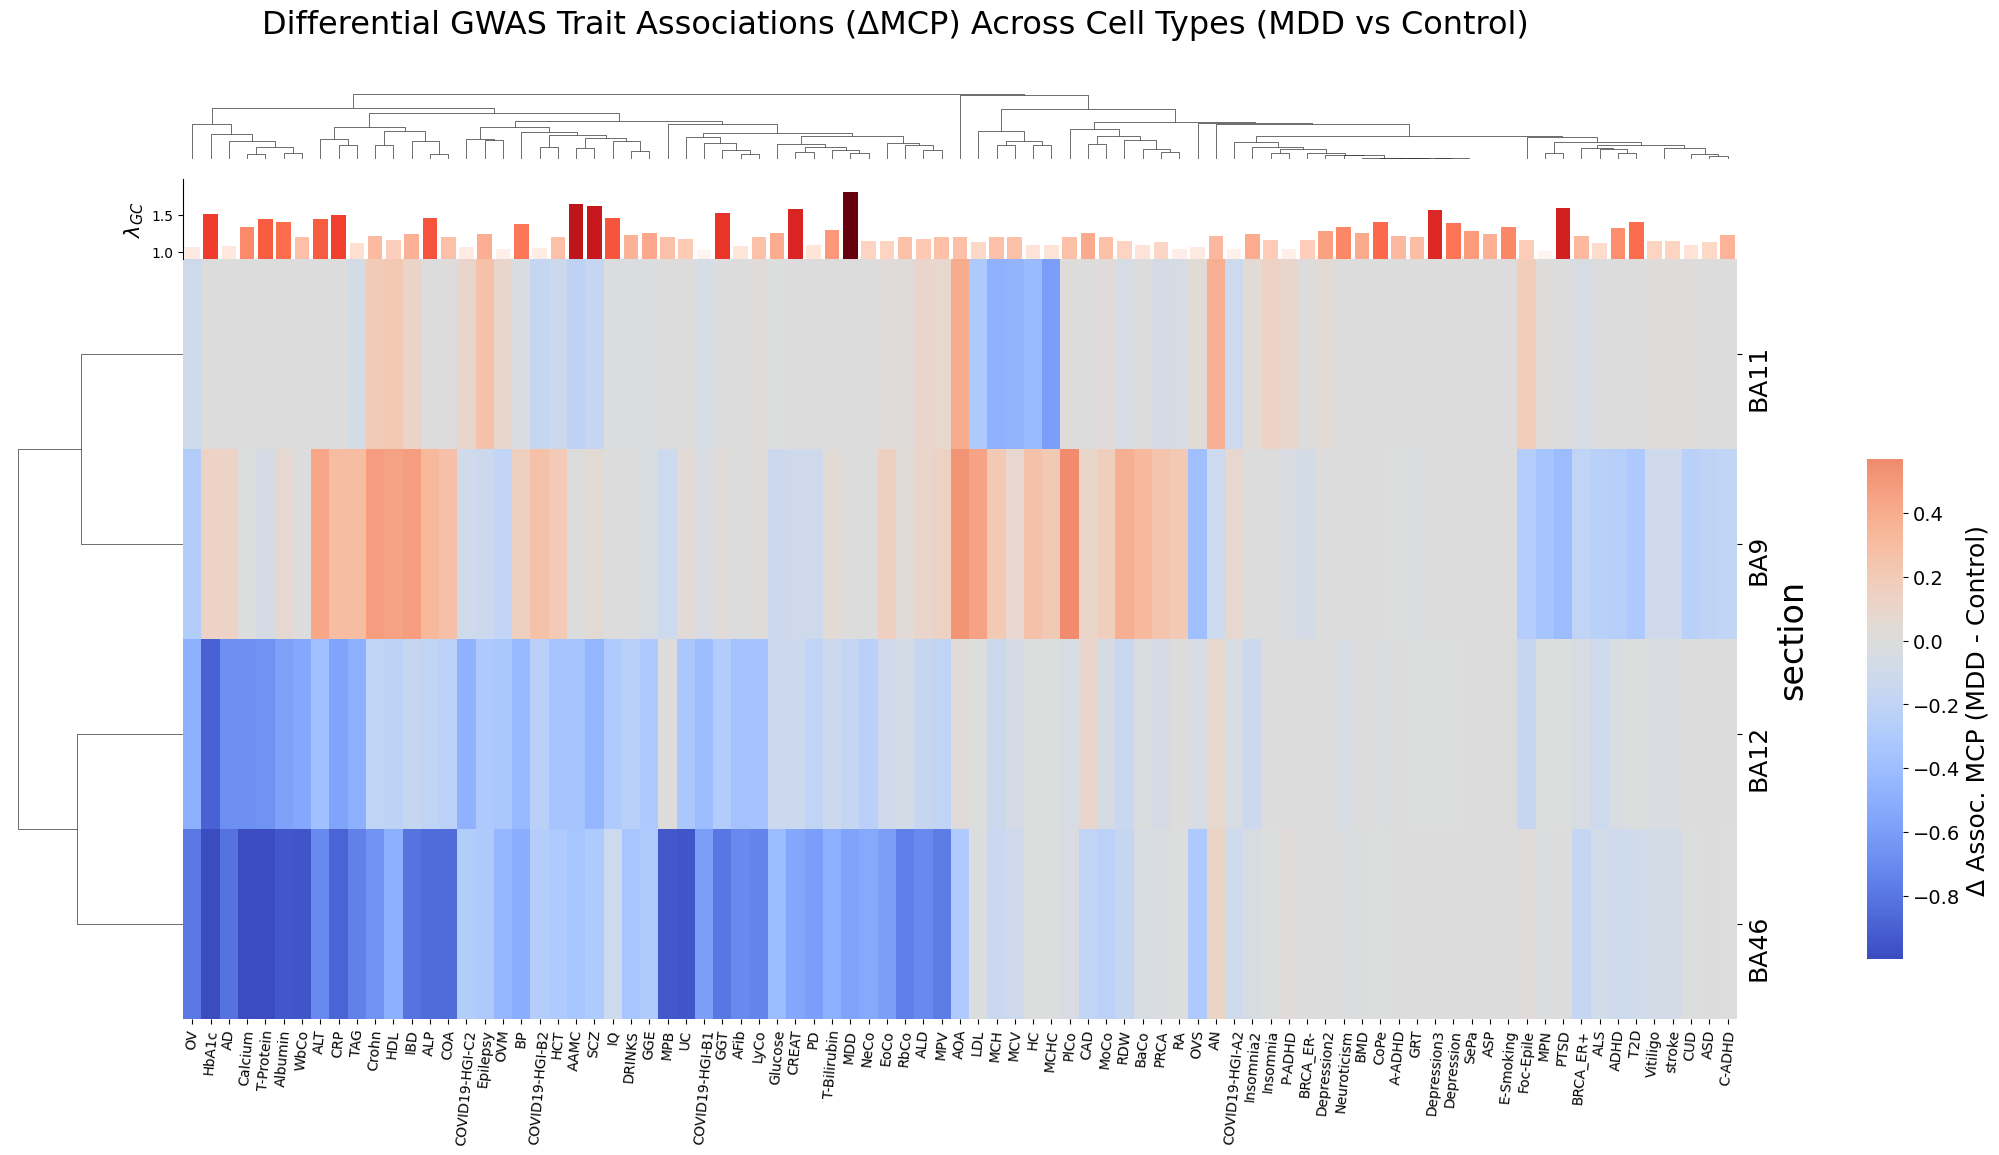

In [14]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ================================
# 1. 路径设置
# ================================
data_dir = "/biostack/home/suchenyi/graduate/scdrs/downstream_hg38"
gc_file = "/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv"

# ================================
# 2. 自动读取 traits
# ================================
traits = [
    f.replace(".scdrs_group.con_section", "")
    for f in os.listdir(data_dir)
    if f.endswith(".scdrs_group.con_section")
]

traits = sorted(traits)
print(f"共读取 {len(traits)} 个 traits")

# ================================
# 3. 读取 λGC 并筛选 traits
# ================================
df_gc = pd.read_csv(gc_file, sep="\t")
df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")

valid_traits = df_gc[df_gc["Lambda_GC"] <= 2].index.tolist()
traits_filtered = [t for t in traits if t in valid_traits]

print(f"原始 traits 数量: {len(traits)}")
print(f"λGC<=2 后剩余: {len(traits_filtered)}")

# ================================
# 4. 计算 ΔMCP
# ================================
dict_delta = {}

for trait in traits_filtered:
    file_path = os.path.join(data_dir, f"{trait}.scdrs_group.con_section")
    
    if not os.path.exists(file_path):
        continue
    
    df = pd.read_csv(file_path, sep="\t")
    
    # 拆分 group → condition + celltype
    df[["condition", "section"]] = df["group"].str.split("&", expand=True)
    
    # pivot
    df_wide = df.pivot(index="section", columns="condition", values="assoc_mcp")
    
    # 检查是否有 C 和 S
    if not {"C", "S"}.issubset(df_wide.columns):
        continue
    
    # 计算 ΔMCP
    df_wide["delta"] = df_wide["S"] - df_wide["C"]
    
    dict_delta[trait] = df_wide["delta"]

# 合并为矩阵
df_delta = pd.DataFrame(dict_delta)

# 行排序（保证一致）
df_delta = df_delta.sort_index()

# ================================
# 5. 处理 λGC 顺序
# ================================
lambda_gc_values = []
for t in df_delta.columns:
    if t in df_gc.index:
        lambda_gc_values.append(df_gc.loc[t, "Lambda_GC"])
    else:
        lambda_gc_values.append(np.nan)

lambda_gc_values = np.array(lambda_gc_values, dtype=float)
lambda_gc_values = np.nan_to_num(lambda_gc_values, nan=1.0, posinf=1.0, neginf=1.0)

# ================================
# 6. 画 clustermap（ΔMCP）
# ================================
g = sns.clustermap(
    df_delta,
    cmap="coolwarm",
    center=0, 
    figsize=(18, 10),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=(1.04, 0.2, 0.02, 0.5),
    cbar_kws={"label": "Δ Assoc. MCP (MDD - Control)"}
)

# ================================
# 7. 获取聚类顺序
# ================================
col_order = g.dendrogram_col.reordered_ind
ordered_traits = [df_delta.columns[i] for i in col_order]
ordered_gc = [df_gc.loc[t, "Lambda_GC"] if t in df_gc.index else 1.0 for t in ordered_traits]

# ================================
# 8. 调整 dendrogram 位置
# ================================
col_dendro_ax = g.ax_col_dendrogram
pos = col_dendro_ax.get_position()

col_dendro_ax.set_position([
    pos.x0,
    pos.y0 + 0.1,
    pos.width,
    pos.height * 0.8
])

# ================================
# 9. λGC barplot
# ================================
bar_ax = g.fig.add_axes([
    pos.x0,
    pos.y0,
    pos.width,
    0.08
])

bar_ax.set_xlim(g.ax_heatmap.get_xlim())

x_pos = np.arange(len(ordered_traits)) + 0.5

norm = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors = [cm.Reds(norm(val)) for val in ordered_gc]

bar_ax.bar(x_pos, ordered_gc, color=colors, width=0.8, align='center')

bar_ax.set_xticks([])
bar_ax.set_ylabel("$\\lambda_{GC}$", fontsize=15)

y_min = min(ordered_gc) * 0.9
bar_ax.set_ylim(y_min, max(ordered_gc) * 1.1)

bar_ax.spines[["top", "right", "bottom"]].set_visible(False)

# ================================
# 10. 标签优化
# ================================
heatmap_ax = g.ax_heatmap

heatmap_ax.set_xticklabels(
    ordered_traits,
    rotation=85,
    fontsize=10
)

heatmap_ax.set_yticklabels(
    heatmap_ax.get_yticklabels(),
    fontsize=18
)
heatmap_ax.yaxis.label.set_size(24)
g.ax_cbar.yaxis.label.set_size(18)     # 色条标题 "Δ Assoc. MCP" 字体大小
g.ax_cbar.tick_params(labelsize=14)    # 顺便调色条刻度字体（可选）
# ================================
# 11. 标题 & 保存
# ================================
g.fig.suptitle(
    "Differential GWAS Trait Associations (ΔMCP) Across Cell Types (MDD vs Control)",
    fontsize=23,
    y=1.15
)

plt.savefig(
    "scDRS_deltaMCP_conSection_lambdaGC_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "scDRS_deltaMCP_conSection_lambdaGC_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

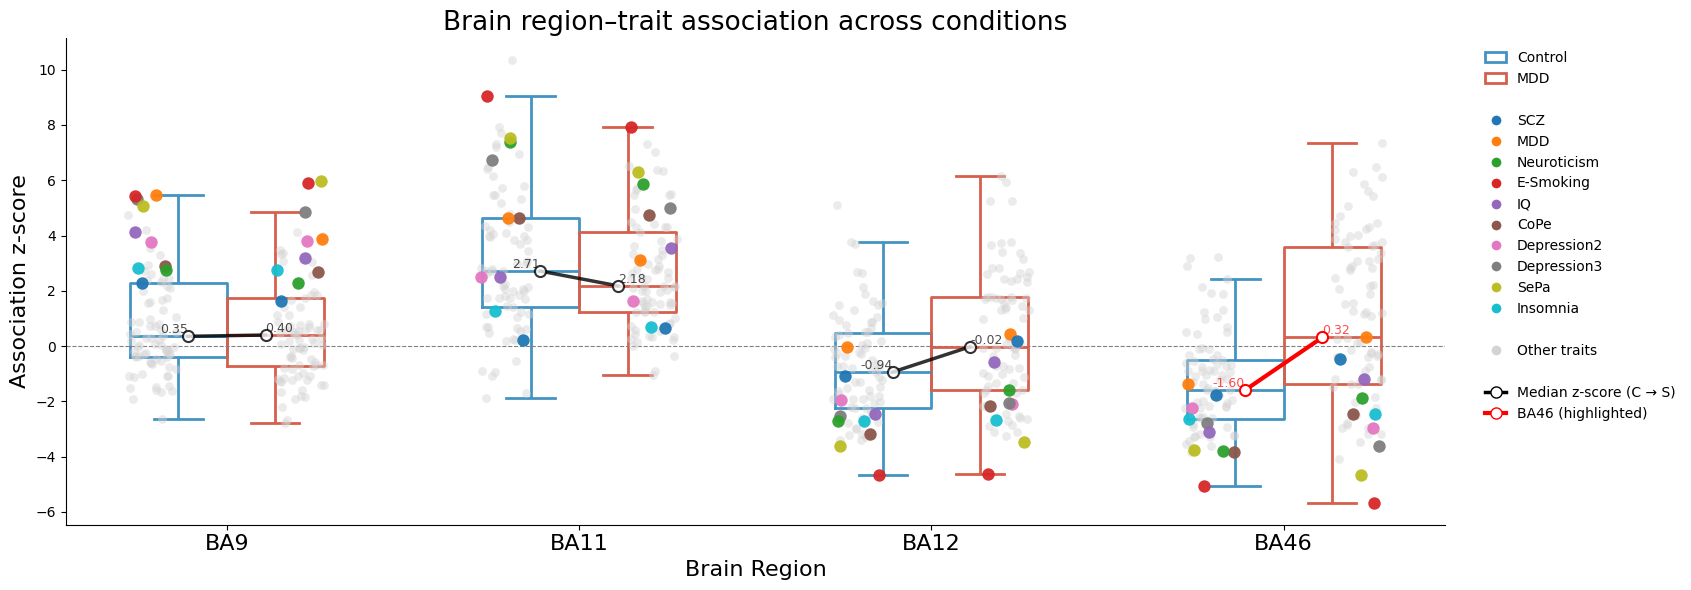

In [5]:
import matplotlib.patches as mpatches
from adjustText import adjust_text
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

LABEL_TRAITS = [
    "SCZ", "MDD", "Neuroticism", "E-Smoking", "IQ",
    "CoPe", "Depression2", "Depression3", "SePa", "Insomnia"
]

trait_palette = dict(zip(LABEL_TRAITS, sns.color_palette("tab10", len(LABEL_TRAITS))))

fig, ax = plt.subplots(figsize=(17, 6))

# ── 1. Boxplot ────────────────────────────────────────────────────
sns.boxplot(
    data=all_df,
    x="region", y="assoc_mcz",
    hue="condition",
    palette={"C": "#4393c3", "S": "#d6604d"},
    width=0.55, showfliers=False,
    linewidth=2.0, fill=False,
    ax=ax
)
ax.get_legend().remove()

# ── 2. Scatter ────────────────────────────────────────────────────
OFFSETS = {"C": -0.21, "S": 0.21}
rng = np.random.default_rng(42)

for i, region in enumerate(region_order):
    for cond in ["C", "S"]:
        sub = all_df[(all_df["region"] == region) & (all_df["condition"] == cond)]
        x0  = i + OFFSETS[cond]

        for _, row in sub.iterrows():
            jitter   = rng.uniform(-0.07, 0.07)
            trait    = row["trait"]
            is_label = trait in LABEL_TRAITS

            ax.scatter(
                x0 + jitter, row["assoc_mcz"],
                color      = trait_palette[trait] if is_label else "lightgray",
                s          = 80 if is_label else 40,
                alpha      = 0.95 if is_label else 0.45,
                zorder     = 5 if is_label else 3,
                linewidths = 0,
            )

# ── 3. 添加C和S之间的z-score连线（使用中位数）────────────────────
for i, region in enumerate(region_order):
    # 计算Control和MDD条件下该脑区的z-score中位数
    c_median = all_df[(all_df["region"] == region) & (all_df["condition"] == "C")]["assoc_mcz"].median()
    s_median = all_df[(all_df["region"] == region) & (all_df["condition"] == "S")]["assoc_mcz"].median()
    
    # 连线的x坐标：C和S boxplot的中心位置
    x_c = i + OFFSETS["C"] + 0.1  # 调整到boxplot中心偏右
    x_s = i + OFFSETS["S"] - 0.1  # 调整到boxplot中心偏左
    
    # 判断是否为BA46脑区，设置不同颜色
    if region == "BA46":
        line_color = "red"
        marker_color = "red"
        line_width = 3.0
        alpha_value = 1.0
    else:
        line_color = "black"
        marker_color = "black"
        line_width = 2.5
        alpha_value = 0.8
    
    # 绘制连线
    ax.plot([x_c, x_s], [c_median, s_median], 
            color=line_color, linewidth=line_width, alpha=alpha_value, 
            linestyle="-", marker="o", markersize=8,
            markerfacecolor="white", markeredgecolor=marker_color,
            markeredgewidth=1.5, zorder=10)
    
    # 可选：在中位数点旁边添加数值标签
    text_color = "red" if region == "BA46" else "black"
    ax.text(x_c, c_median, f"{c_median:.2f}", 
            fontsize=9, ha='right', va='bottom', alpha=0.7, color=text_color)
    ax.text(x_s, s_median, f"{s_median:.2f}", 
            fontsize=9, ha='left', va='bottom', alpha=0.7, color=text_color)

# ── 4. 图例 ───────────────────────────────────────────────────────
cond_handles = [
    mpatches.Patch(facecolor="none", edgecolor="#4393c3", linewidth=2, label="Control"),
    mpatches.Patch(facecolor="none", edgecolor="#d6604d", linewidth=2, label="MDD"),
]
trait_handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=trait_palette[t], markersize=8, label=t)
    for t in LABEL_TRAITS
]
other_handle = plt.Line2D([0], [0], marker="o", color="w",
                           markerfacecolor="lightgray", markersize=8,
                           label="Other traits")

# 添加中位数连线示例到图例
median_line_handle = plt.Line2D([0], [0], color="black", linewidth=2.5,
                                 marker="o", markerfacecolor="white",
                                 markeredgecolor="black", markersize=8,
                                 label="Median z-score (C → S)")

# 添加BA46特殊连线示例
ba46_line_handle = plt.Line2D([0], [0], color="red", linewidth=3.0,
                              marker="o", markerfacecolor="white",
                              markeredgecolor="red", markersize=8,
                              label="BA46 (highlighted)")

ax.legend(
    handles=cond_handles
            + [plt.Line2D([], [], color="none", label="")]   # 空行分隔
            + trait_handles
            + [plt.Line2D([], [], color="none", label="")]   # 空行分隔
            + [other_handle]
            + [plt.Line2D([], [], color="none", label="")]   # 空行分隔
            + [median_line_handle]
            + [ba46_line_handle],
    frameon=False,
    bbox_to_anchor=(1.02, 1), loc="upper left",
    fontsize=10, title_fontsize=13,
    handlelength=1.5,
)

# ── 5. 修饰 ───────────────────────────────────────────────────────
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Brain Region", fontsize=16)
ax.set_ylabel("Association z-score", fontsize=16)
ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(region_order, fontsize=16)
ax.set_title("Brain region–trait association across conditions", fontsize=19)
sns.despine()
plt.tight_layout()
plt.savefig("assoc_mcz_region_alltraits_BA46_highlighted.pdf", dpi=300, bbox_inches="tight")
plt.savefig("assoc_mcz_region_alltraits_BA46_highlighted.png", dpi=300, bbox_inches="tight")
plt.show()

共读取 90 个 traits
原始 traits 数量: 90
λGC<=2 后剩余: 85


/tmp/ipykernel_22548/611922012.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm_r")


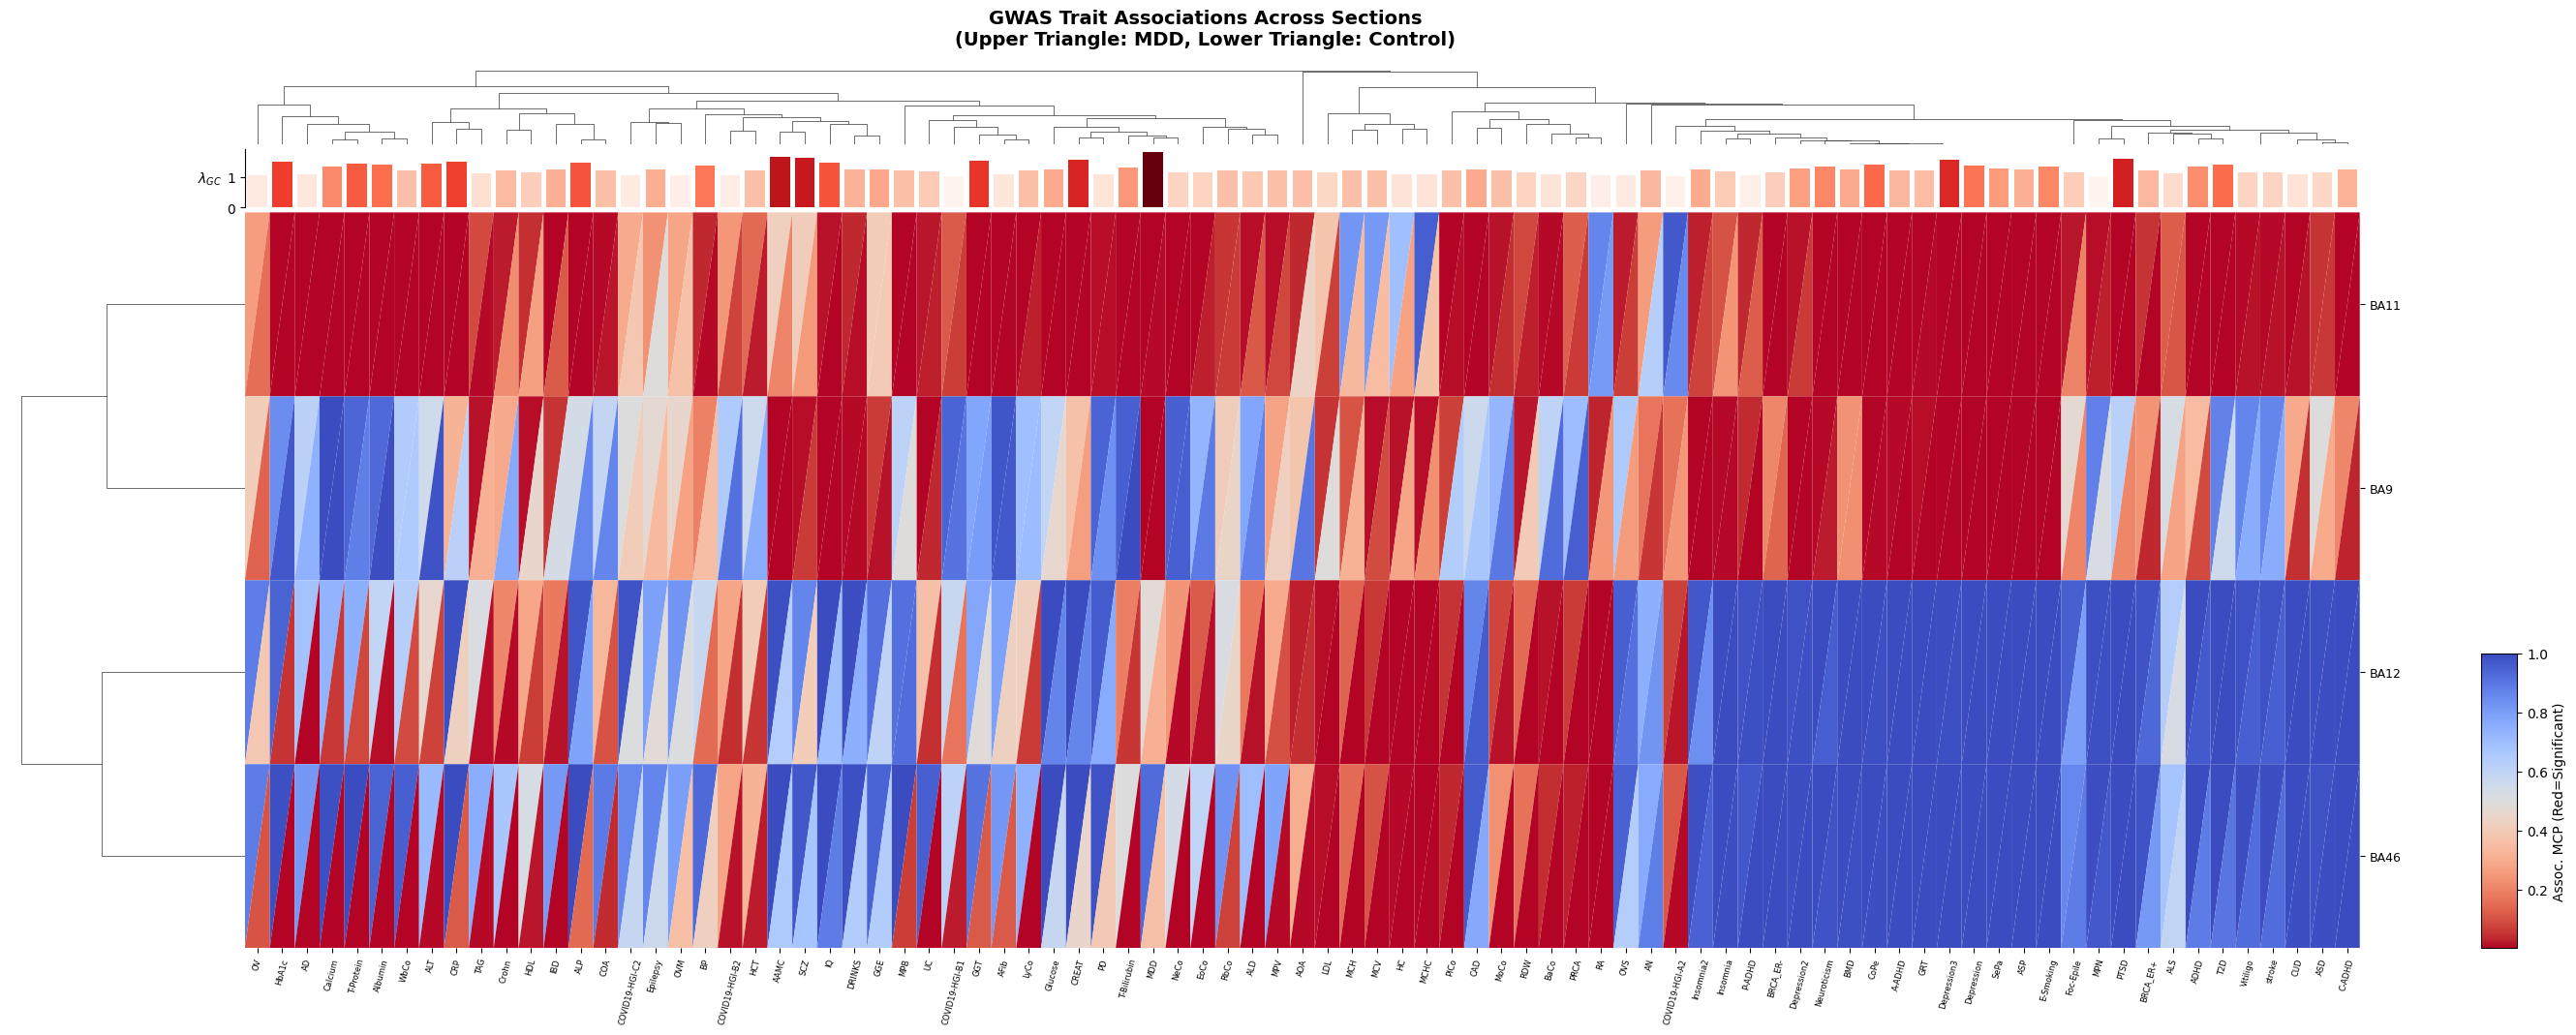

In [6]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.cm import ScalarMappable

# ================================
# 1. 路径设置
# ================================
data_dir = "/biostack/home/suchenyi/graduate/scdrs/downstream_hg38"
gc_file = "/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv"

# ================================
# 2. 自动读取 traits
# ================================
traits = [
    f.replace(".scdrs_group.con_section", "")
    for f in os.listdir(data_dir)
    if f.endswith(".scdrs_group.con_section")
]
traits = sorted(traits)

print(f"共读取 {len(traits)} 个 traits")

# ================================
# 3. 读取 λGC 并筛选
# ================================
df_gc = pd.read_csv(gc_file, sep="\t")
df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")

valid_traits = df_gc[df_gc["Lambda_GC"] <= 2].index.tolist()
traits_filtered = [t for t in traits if t in valid_traits]

print(f"原始 traits 数量: {len(traits)}")
print(f"λGC<=2 后剩余: {len(traits_filtered)}")

# ================================
# 4. 构建 S / C 矩阵
# ================================
dict_S = {}
dict_C = {}

for trait in traits_filtered:
    file_path = os.path.join(data_dir, f"{trait}.scdrs_group.con_section")
    
    if not os.path.exists(file_path):
        continue
    
    df = pd.read_csv(file_path, sep="\t")
    
    df[["condition", "section"]] = df["group"].str.split("&", expand=True)
    
    df_wide = df.pivot(index="section", columns="condition", values="assoc_mcp")
    
    if not {"C", "S"}.issubset(df_wide.columns):
        continue
    
    dict_S[trait] = df_wide["S"]
    dict_C[trait] = df_wide["C"]

df_S = pd.DataFrame(dict_S).sort_index()
df_C = pd.DataFrame(dict_C).sort_index()

# ================================
# 5. ΔMCP 用于聚类
# ================================
df_delta = df_S - df_C

# ================================
# 6. clustermap（只用于拿聚类顺序）
# ================================
g = sns.clustermap(
    df_delta,
    cmap="coolwarm_r",
    center=0,
    figsize=(25, 10),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=None
)

# ================================
# 7. 获取排序
# ================================
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind

df_S = df_S.iloc[row_order, col_order]
df_C = df_C.iloc[row_order, col_order]

ordered_traits = df_S.columns

# ================================
# 8. λGC 顺序
# ================================
ordered_gc = [
    df_gc.loc[t, "Lambda_GC"] if t in df_gc.index else 1.0
    for t in ordered_traits
]

# ================================
# 9. 清空 heatmap
# ================================
g.ax_heatmap.clear()
ax = g.ax_heatmap

# ================================
# 10. 颜色范围与反转 (MCP 越小越红)
# ================================
vmin = min(df_S.min().min(), df_C.min().min())
vmax = max(df_S.max().max(), df_C.max().max())

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
# 使用 _r 反转色标：小值红，大值蓝
cmap = cm.get_cmap("coolwarm_r")

# ================================
# 11. 画三角形 heatmap
# ================================
n_rows, n_cols = df_S.shape

for i in range(n_rows):
    for j in range(n_cols):
        val_S = df_S.iloc[i, j]
        val_C = df_C.iloc[i, j]

        x = j
        y = i

        # 左下：Control
        tri_C = patches.Polygon(
            [(x, y), (x+1, y), (x, y+1)],
            facecolor=cmap(norm(val_C)),
            edgecolor='none'
        )

        # 右上：MDD
        tri_S = patches.Polygon(
            [(x+1, y+1), (x+1, y), (x, y+1)],
            facecolor=cmap(norm(val_S)),
            edgecolor='none'
        )

        ax.add_patch(tri_C)
        ax.add_patch(tri_S)

# ================================
# 12. 轴设置
# ================================
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.invert_yaxis()

ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(ordered_traits, rotation=75, fontsize=6)

ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(df_S.index, fontsize=9)

# ================================
# 13. λGC barplot (紧凑对齐逻辑)
# ================================
hm_pos = g.ax_heatmap.get_position()

# 1. 设置 barplot：紧贴 heatmap 顶部，间距 0.005
bar_height = 0.06
bar_y0 = hm_pos.y1 + 0.005 
bar_ax = g.fig.add_axes([
    hm_pos.x0, 
    bar_y0, 
    hm_pos.width, 
    bar_height
])

# 2. 设置聚类树：紧贴 barplot 顶部，间距 0.005
dendro_height = 0.08
dendro_y0 = bar_y0 + bar_height + 0.005
g.ax_col_dendrogram.set_position([
    hm_pos.x0, 
    dendro_y0, 
    hm_pos.width, 
    dendro_height
])

# 绘图逻辑
x_pos = np.arange(len(ordered_traits)) + 0.5
norm_gc = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors_gc = [cm.Reds(norm_gc(val)) for val in ordered_gc]

bar_ax.bar(x_pos, ordered_gc, color=colors_gc, width=0.8)
bar_ax.set_xlim(0, n_cols)
bar_ax.set_xticks([])
bar_ax.set_ylabel("$\\lambda_{GC}$", fontsize=10, rotation=0, ha='right', va='center')
bar_ax.spines[["top", "right", "bottom"]].set_visible(False)

# ================================
# 14. colorbar (侧边定位)
# ================================
# 将 0.1 改为 0.05 左右，如果还是重叠 y 轴 label 再调大
cbar_ax = g.fig.add_axes([
    hm_pos.x1 + 0.05, 
    hm_pos.y0, 
    0.015, 
    hm_pos.height * 0.4
])

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Assoc. MCP (Red=Significant)", fontsize=10)

# ================================
# 15. 标题 & 保存 (动态定位)
# ================================
# 标题位置设置在聚类树顶端再往上一点
# 计算聚类树的顶端位置
top_of_plot = dendro_y0 + dendro_height

g.fig.suptitle(
    "GWAS Trait Associations Across Sections\n(Upper Triangle: MDD, Lower Triangle: Control)",
    fontsize=14,
    fontweight='bold',
    y = top_of_plot + 0.06  # 动态计算，确保不重叠
)

# 保存时去掉 subplots_adjust，完全依赖定位和 tight 布局
plt.savefig(
    "scDRS_triangle_MCP_heatmap_lambdaGC_section.pdf",
    dpi=300,
    bbox_inches="tight" 
)
plt.savefig(
    "scDRS_triangle_MCP_heatmap_lambdaGC_section.png",
    dpi=300,
    bbox_inches="tight" 
)

plt.show()

共读取 90 个 traits
原始 traits 数量: 90
λGC<=2 后剩余: 85


/tmp/ipykernel_21462/312566495.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm_r")


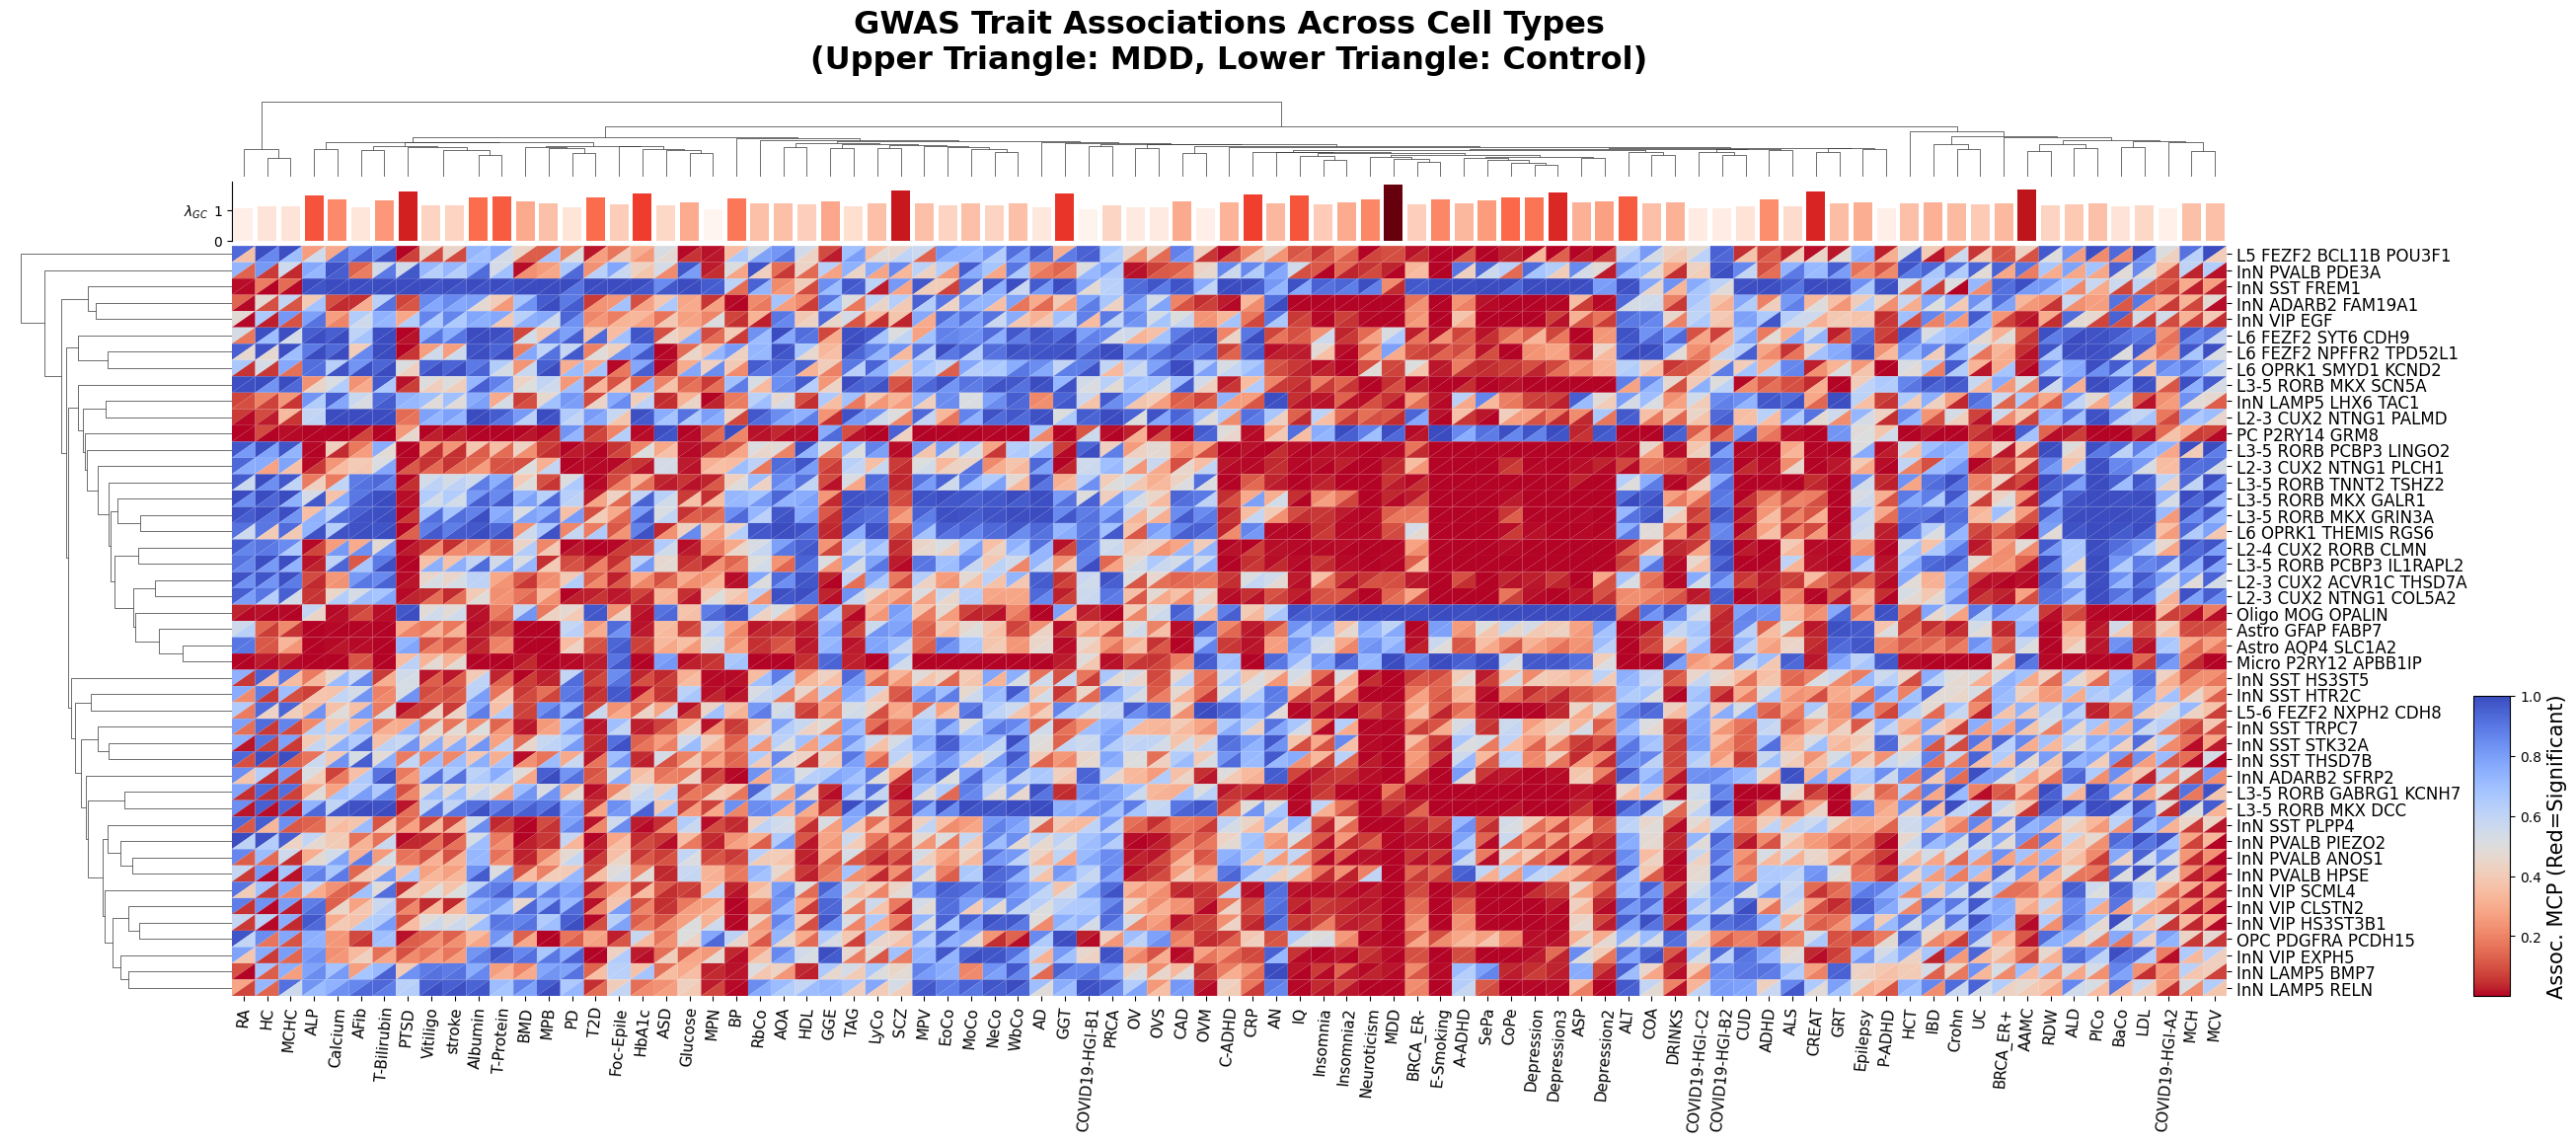

In [26]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.cm import ScalarMappable

# ================================
# 1. 路径设置
# ================================
data_dir = "/biostack/home/suchenyi/graduate/scdrs/downstream_hg38"
gc_file = "/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv"

# ================================
# 2. 自动读取 traits
# ================================
traits = [
    f.replace(".scdrs_group.con_cts", "")
    for f in os.listdir(data_dir)
    if f.endswith(".scdrs_group.con_cts")
]
traits = sorted(traits)

print(f"共读取 {len(traits)} 个 traits")

# ================================
# 3. 读取 λGC 并筛选
# ================================
df_gc = pd.read_csv(gc_file, sep="\t")
df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")

valid_traits = df_gc[df_gc["Lambda_GC"] <= 2].index.tolist()
traits_filtered = [t for t in traits if t in valid_traits]

print(f"原始 traits 数量: {len(traits)}")
print(f"λGC<=2 后剩余: {len(traits_filtered)}")

# ================================
# 4. 构建 S / C 矩阵
# ================================
dict_S = {}
dict_C = {}

for trait in traits_filtered:
    file_path = os.path.join(data_dir, f"{trait}.scdrs_group.con_cts")
    
    if not os.path.exists(file_path):
        continue
    
    df = pd.read_csv(file_path, sep="\t")
    
    df[["condition", "section"]] = df["group"].str.split("&", expand=True)
    
    df_wide = df.pivot(index="section", columns="condition", values="assoc_mcp")
    
    if not {"C", "S"}.issubset(df_wide.columns):
        continue
    
    dict_S[trait] = df_wide["S"]
    dict_C[trait] = df_wide["C"]

df_S = pd.DataFrame(dict_S).sort_index()
df_C = pd.DataFrame(dict_C).sort_index()

# ================================
# 5. ΔMCP 用于聚类
# ================================
df_delta = df_S - df_C

# ================================
# 6. clustermap（只用于拿聚类顺序）
# ================================
g = sns.clustermap(
    df_delta,
    cmap="coolwarm_r",
    center=0,
    figsize=(25, 10),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=None
)

# ================================
# 7. 获取排序
# ================================
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind

df_S = df_S.iloc[row_order, col_order]
df_C = df_C.iloc[row_order, col_order]

ordered_traits = df_S.columns

# ================================
# 8. λGC 顺序
# ================================
ordered_gc = [
    df_gc.loc[t, "Lambda_GC"] if t in df_gc.index else 1.0
    for t in ordered_traits
]

# ================================
# 9. 清空 heatmap
# ================================
g.ax_heatmap.clear()
ax = g.ax_heatmap

# ================================
# 10. 颜色范围与反转 (MCP 越小越红)
# ================================
vmin = min(df_S.min().min(), df_C.min().min())
vmax = max(df_S.max().max(), df_C.max().max())

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
# 使用 _r 反转色标：小值红，大值蓝
cmap = cm.get_cmap("coolwarm_r")

# ================================
# 11. 画三角形 heatmap
# ================================
n_rows, n_cols = df_S.shape

for i in range(n_rows):
    for j in range(n_cols):
        val_S = df_S.iloc[i, j]
        val_C = df_C.iloc[i, j]

        x = j
        y = i

        # 左下：Control
        tri_C = patches.Polygon(
            [(x, y), (x+1, y), (x, y+1)],
            facecolor=cmap(norm(val_C)),
            edgecolor='none'
        )

        # 右上：MDD
        tri_S = patches.Polygon(
            [(x+1, y+1), (x+1, y), (x, y+1)],
            facecolor=cmap(norm(val_S)),
            edgecolor='none'
        )

        ax.add_patch(tri_C)
        ax.add_patch(tri_S)

# ================================
# 12. 轴设置
# ================================
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.invert_yaxis()

ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(ordered_traits, rotation=85, fontsize=11)

ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(df_S.index, fontsize=12)

# ================================
# 13. λGC barplot (紧凑对齐逻辑)
# ================================
hm_pos = g.ax_heatmap.get_position()

# 1. 设置 barplot：紧贴 heatmap 顶部，间距 0.005
bar_height = 0.06
bar_y0 = hm_pos.y1 + 0.005 
bar_ax = g.fig.add_axes([
    hm_pos.x0, 
    bar_y0, 
    hm_pos.width, 
    bar_height
])

# 2. 设置聚类树：紧贴 barplot 顶部，间距 0.005
dendro_height = 0.08
dendro_y0 = bar_y0 + bar_height + 0.005
g.ax_col_dendrogram.set_position([
    hm_pos.x0, 
    dendro_y0, 
    hm_pos.width, 
    dendro_height
])

# 绘图逻辑
x_pos = np.arange(len(ordered_traits)) + 0.5
norm_gc = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors_gc = [cm.Reds(norm_gc(val)) for val in ordered_gc]

bar_ax.bar(x_pos, ordered_gc, color=colors_gc, width=0.8)
bar_ax.set_xlim(0, n_cols)
bar_ax.set_xticks([])
bar_ax.set_ylabel("$\\lambda_{GC}$", fontsize=10, rotation=0, ha='right', va='center')
bar_ax.spines[["top", "right", "bottom"]].set_visible(False)

# ================================
# 14. colorbar (侧边定位)
# ================================
# 将 0.1 改为 0.05 左右，如果还是重叠 y 轴 label 再调大
cbar_ax = g.fig.add_axes([
    hm_pos.x1 + 0.1, 
    hm_pos.y0, 
    0.015, 
    hm_pos.height * 0.4
])

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Assoc. MCP (Red=Significant)", fontsize=15)

# ================================
# 15. 标题 & 保存 (动态定位)
# ================================
# 标题位置设置在聚类树顶端再往上一点
# 计算聚类树的顶端位置
top_of_plot = dendro_y0 + dendro_height

g.fig.suptitle(
    "GWAS Trait Associations Across Cell Types\n(Upper Triangle: MDD, Lower Triangle: Control)",
    fontsize=23,
    fontweight='bold',
    y = top_of_plot + 0.09  # 动态计算，确保不重叠
)

# 保存时去掉 subplots_adjust，完全依赖定位和 tight 布局
plt.savefig(
    "scDRS_triangle_MCP_heatmap_lambdaGC_dominantlabels.pdf",
    dpi=300,
    bbox_inches="tight" 
)
plt.savefig(
    "scDRS_triangle_MCP_heatmap_lambdaGC_dominantlabels.png",
    dpi=300,
    bbox_inches="tight" 
)

plt.show()

共读取 90 个 traits
原始 traits 数量: 90
λGC<=2 后剩余: 85


/tmp/ipykernel_22548/245911370.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm_r")


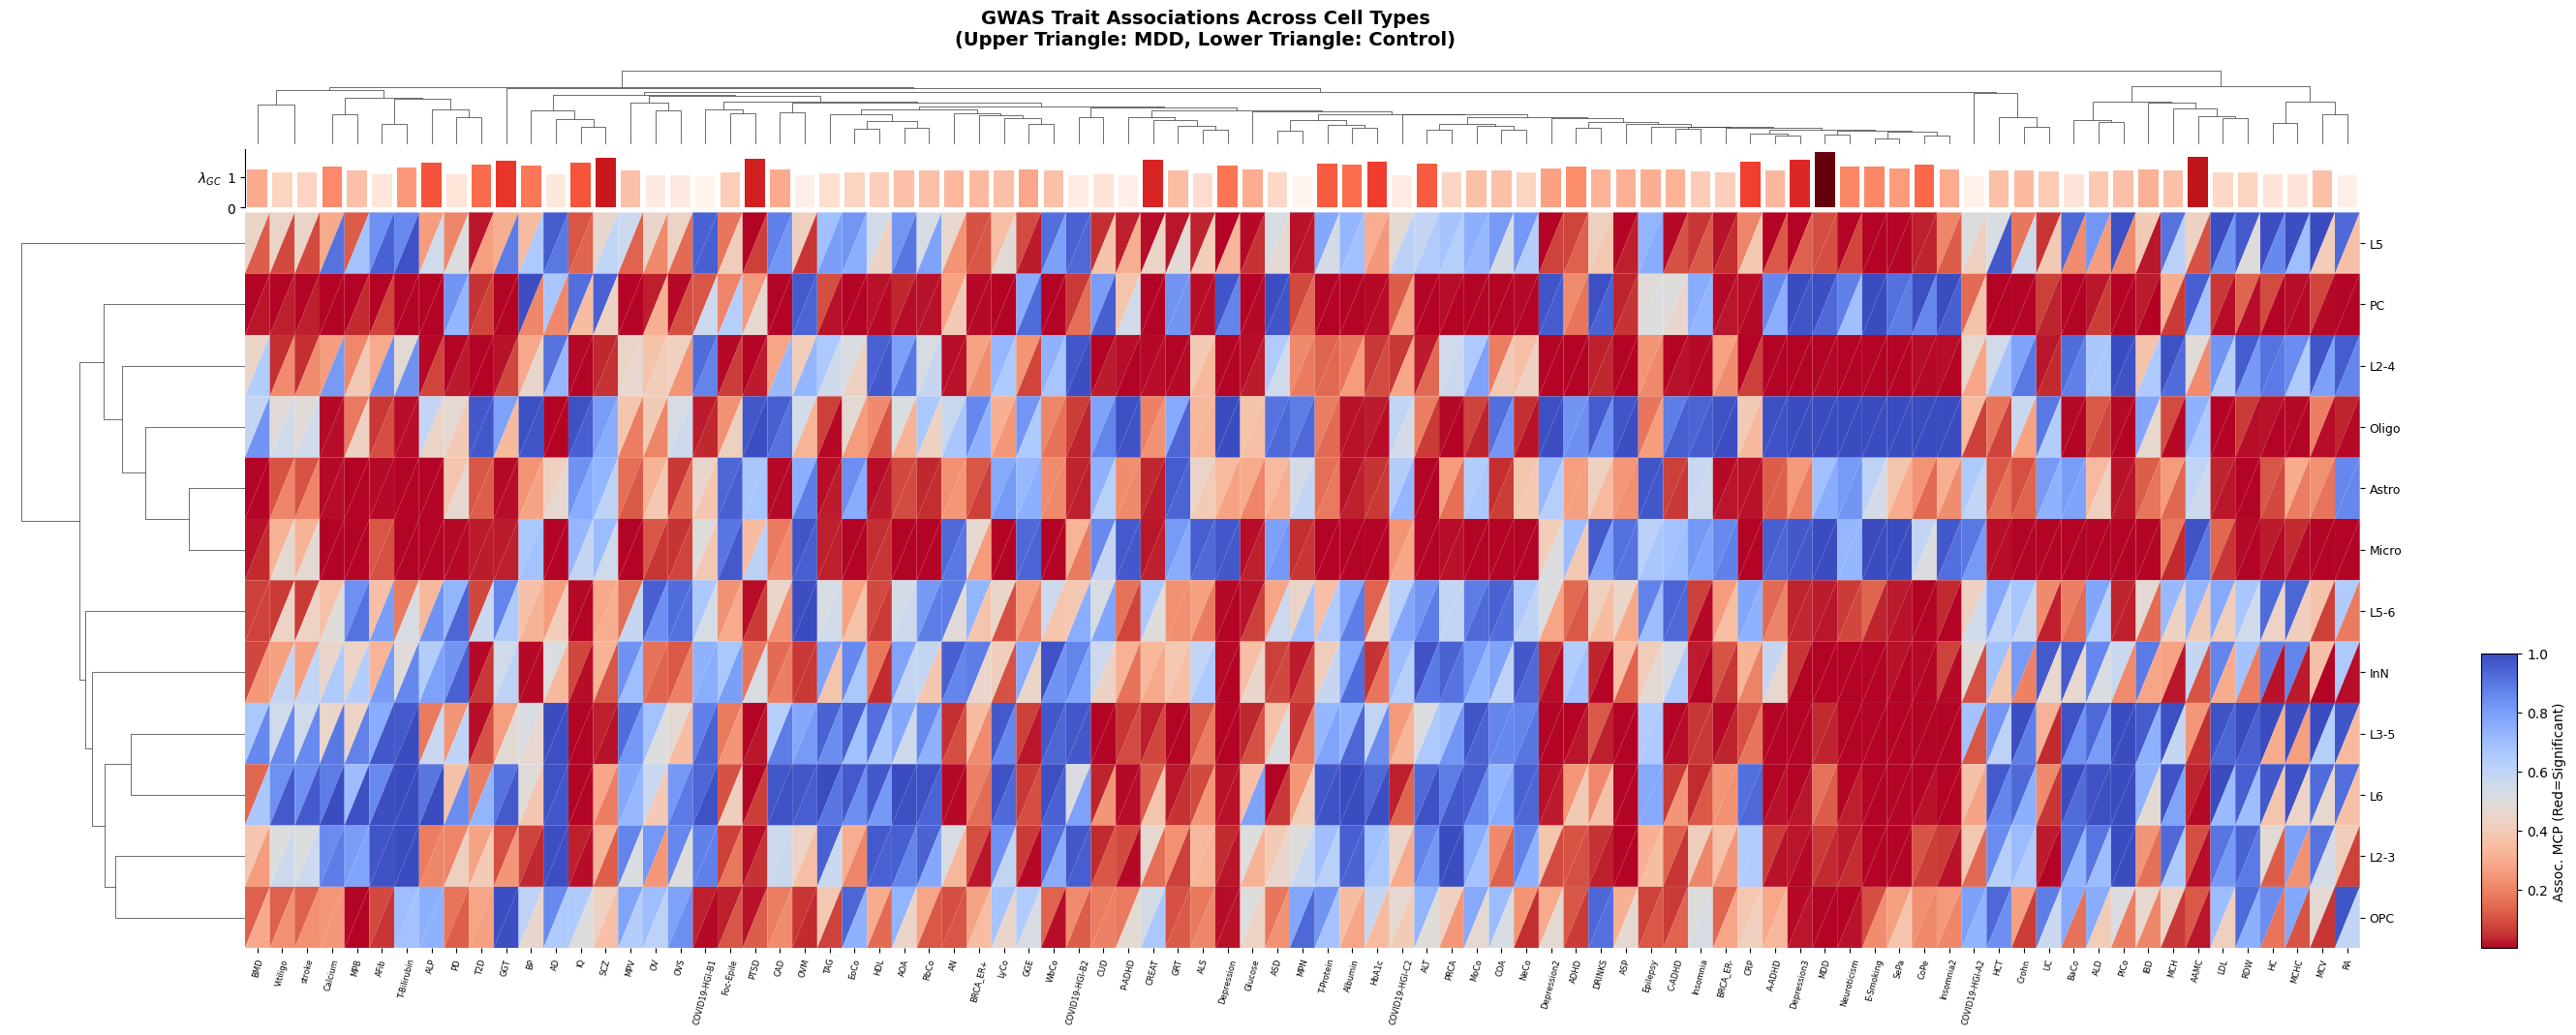

In [5]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.cm import ScalarMappable

# ================================
# 1. 路径设置
# ================================
data_dir = "/biostack/home/suchenyi/graduate/scdrs/downstream_hg38"
gc_file = "/biostack/home/suchenyi/graduate/scdrs/lambda_GC_all.tsv"

# ================================
# 2. 自动读取 traits
# ================================
traits = [
    f.replace(".scdrs_group.con_ct", "")
    for f in os.listdir(data_dir)
    if f.endswith(".scdrs_group.con_ct")
]
traits = sorted(traits)

print(f"共读取 {len(traits)} 个 traits")

# ================================
# 3. 读取 λGC 并筛选
# ================================
df_gc = pd.read_csv(gc_file, sep="\t")
df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")

valid_traits = df_gc[df_gc["Lambda_GC"] <= 2].index.tolist()
traits_filtered = [t for t in traits if t in valid_traits]

print(f"原始 traits 数量: {len(traits)}")
print(f"λGC<=2 后剩余: {len(traits_filtered)}")

# ================================
# 4. 构建 S / C 矩阵
# ================================
dict_S = {}
dict_C = {}

for trait in traits_filtered:
    file_path = os.path.join(data_dir, f"{trait}.scdrs_group.con_ct")
    
    if not os.path.exists(file_path):
        continue
    
    df = pd.read_csv(file_path, sep="\t")
    
    df[["condition", "section"]] = df["group"].str.split("&", expand=True)
    
    df_wide = df.pivot(index="section", columns="condition", values="assoc_mcp")
    
    if not {"C", "S"}.issubset(df_wide.columns):
        continue
    
    dict_S[trait] = df_wide["S"]
    dict_C[trait] = df_wide["C"]

df_S = pd.DataFrame(dict_S).sort_index()
df_C = pd.DataFrame(dict_C).sort_index()

# ================================
# 5. ΔMCP 用于聚类
# ================================
df_delta = df_S - df_C

# ================================
# 6. clustermap（只用于拿聚类顺序）
# ================================
g = sns.clustermap(
    df_delta,
    cmap="coolwarm_r",
    center=0,
    figsize=(25, 10),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=None
)

# ================================
# 7. 获取排序
# ================================
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind

df_S = df_S.iloc[row_order, col_order]
df_C = df_C.iloc[row_order, col_order]

ordered_traits = df_S.columns

# ================================
# 8. λGC 顺序
# ================================
ordered_gc = [
    df_gc.loc[t, "Lambda_GC"] if t in df_gc.index else 1.0
    for t in ordered_traits
]

# ================================
# 9. 清空 heatmap
# ================================
g.ax_heatmap.clear()
ax = g.ax_heatmap

# ================================
# 10. 颜色范围与反转 (MCP 越小越红)
# ================================
vmin = min(df_S.min().min(), df_C.min().min())
vmax = max(df_S.max().max(), df_C.max().max())

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
# 使用 _r 反转色标：小值红，大值蓝
cmap = cm.get_cmap("coolwarm_r")

# ================================
# 11. 画三角形 heatmap
# ================================
n_rows, n_cols = df_S.shape

for i in range(n_rows):
    for j in range(n_cols):
        val_S = df_S.iloc[i, j]
        val_C = df_C.iloc[i, j]

        x = j
        y = i

        # 左下：Control
        tri_C = patches.Polygon(
            [(x, y), (x+1, y), (x, y+1)],
            facecolor=cmap(norm(val_C)),
            edgecolor='none'
        )

        # 右上：MDD
        tri_S = patches.Polygon(
            [(x+1, y+1), (x+1, y), (x, y+1)],
            facecolor=cmap(norm(val_S)),
            edgecolor='none'
        )

        ax.add_patch(tri_C)
        ax.add_patch(tri_S)

# ================================
# 12. 轴设置
# ================================
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.invert_yaxis()

ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(ordered_traits, rotation=75, fontsize=6)

ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(df_S.index, fontsize=9)

# ================================
# 13. λGC barplot (紧凑对齐逻辑)
# ================================
hm_pos = g.ax_heatmap.get_position()

# 1. 设置 barplot：紧贴 heatmap 顶部，间距 0.005
bar_height = 0.06
bar_y0 = hm_pos.y1 + 0.005 
bar_ax = g.fig.add_axes([
    hm_pos.x0, 
    bar_y0, 
    hm_pos.width, 
    bar_height
])

# 2. 设置聚类树：紧贴 barplot 顶部，间距 0.005
dendro_height = 0.08
dendro_y0 = bar_y0 + bar_height + 0.005
g.ax_col_dendrogram.set_position([
    hm_pos.x0, 
    dendro_y0, 
    hm_pos.width, 
    dendro_height
])

# 绘图逻辑
x_pos = np.arange(len(ordered_traits)) + 0.5
norm_gc = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors_gc = [cm.Reds(norm_gc(val)) for val in ordered_gc]

bar_ax.bar(x_pos, ordered_gc, color=colors_gc, width=0.8)
bar_ax.set_xlim(0, n_cols)
bar_ax.set_xticks([])
bar_ax.set_ylabel("$\\lambda_{GC}$", fontsize=10, rotation=0, ha='right', va='center')
bar_ax.spines[["top", "right", "bottom"]].set_visible(False)

# ================================
# 14. colorbar (侧边定位)
# ================================
# 将 0.1 改为 0.05 左右，如果还是重叠 y 轴 label 再调大
cbar_ax = g.fig.add_axes([
    hm_pos.x1 + 0.05, 
    hm_pos.y0, 
    0.015, 
    hm_pos.height * 0.4
])

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Assoc. MCP (Red=Significant)", fontsize=10)

# ================================
# 15. 标题 & 保存 (动态定位)
# ================================
# 标题位置设置在聚类树顶端再往上一点
# 计算聚类树的顶端位置
top_of_plot = dendro_y0 + dendro_height

g.fig.suptitle(
    "GWAS Trait Associations Across Cell Types\n(Upper Triangle: MDD, Lower Triangle: Control)",
    fontsize=14,
    fontweight='bold',
    y = top_of_plot + 0.06  # 动态计算，确保不重叠
)

# 保存时去掉 subplots_adjust，完全依赖定位和 tight 布局
plt.savefig(
    "scDRS_triangle_MCP_heatmap_lambdaGC_dominantlabels_short.pdf",
    dpi=300,
    bbox_inches="tight" 
)
plt.savefig(
    "scDRS_triangle_MCP_heatmap_lambdaGC_dominantlabels_short.png",
    dpi=300,
    bbox_inches="tight" 
)
plt.show()

Saved dual_panel_trait_correlation.pdf / .png


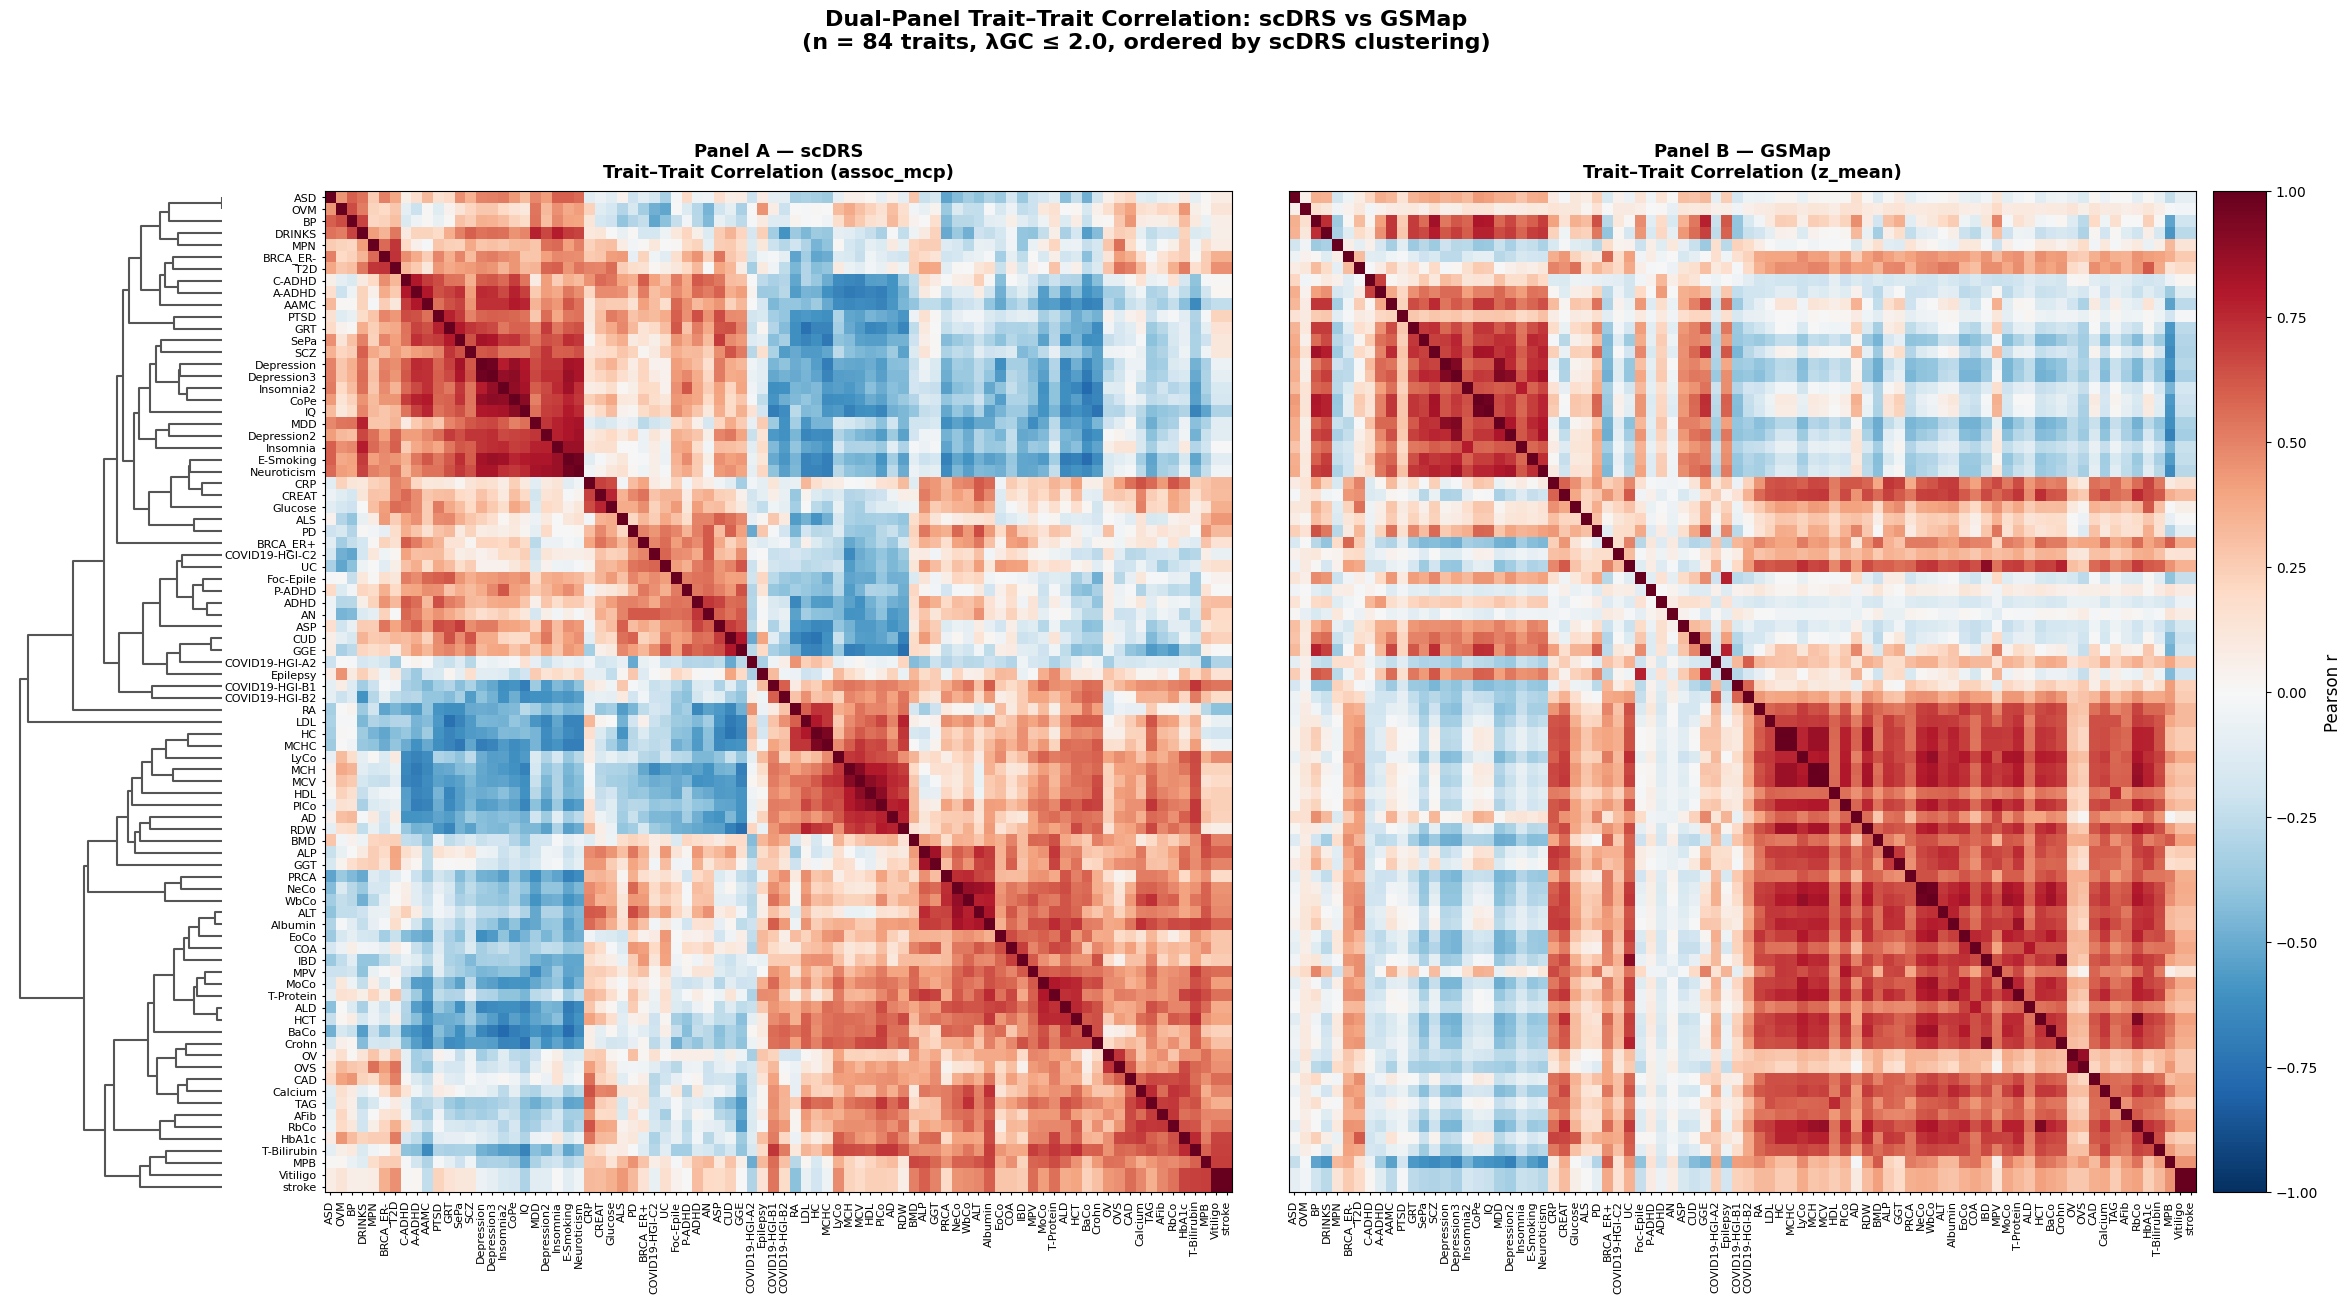

In [31]:

#  ─────────────────────────────────────────────
# 5. Plot
# ─────────────────────────────────────────────
n = len(ordered_traits)
tick_fs = 8    # auto font-size for tick labels
 
fig = plt.figure(figsize=(28, 13))
 
# Layout: dendrogram | Panel A | spacer | Panel B | colorbar
gs = gridspec.GridSpec(
    1, 5,
    figure=fig,
    width_ratios=[1.4, 6, 0.15, 6, 0.35],
    wspace=0.04,
)
 
ax_dendro  = fig.add_subplot(gs[0])
ax_A       = fig.add_subplot(gs[1])
ax_spacer  = fig.add_subplot(gs[2]);  ax_spacer.axis("off")
ax_B       = fig.add_subplot(gs[3])
ax_cbar    = fig.add_subplot(gs[4])
 
# ── dendrogram (left) ───────────────────────
dn = dendrogram(
    Z,
    orientation="left",
    labels=ordered_traits,
    ax=ax_dendro,
    color_threshold=0,
    above_threshold_color="#555",
    link_color_func=lambda k: "#555",
    no_labels=True,
)
ax_dendro.axis("off")
ax_dendro.set_title("", fontsize=1)
 
# Shift the dendrogram left so its right edge doesn't overlap Panel A y-labels.
# This only affects the gap between the dendrogram and Panel A; the two heatmaps
# are completely unaffected.
fig.canvas.draw()                          # force layout so get_position() is accurate
pos_d = ax_dendro.get_position()
pos_A = ax_A.get_position()
# How much do Panel A y-labels extend to the left of the heatmap?
label_width_fig = tick_fs / 72 * 8 / fig.get_figwidth()   # rough estimate in figure coords
overlap = (pos_d.x1 + 0.005) - (pos_A.x0 - label_width_fig)
if overlap > 0:
    ax_dendro.set_position([
        pos_d.x0 - overlap,
        pos_d.y0,
        pos_d.width,
        pos_d.height,
    ])
 
# Both matrices are symmetric; use the same ordered_traits for rows & cols.
# ordered_traits already matches the dendrogram leaf order (leaves_list output).
corr_scdrs_plot = corr_scdrs_c.loc[ordered_traits, ordered_traits]
corr_gsmap_plot = corr_gsmap_c.loc[ordered_traits, ordered_traits]
 
# ── Panel A: scDRS ──────────────────────────
im_A = ax_A.imshow(
    corr_scdrs_plot.values,
    cmap=CORR_CMAP, vmin=VMIN, vmax=VMAX,
    aspect="auto", interpolation="nearest",
)
ax_A.set_xticks(range(n))
ax_A.set_xticklabels(ordered_traits, rotation=90, fontsize=tick_fs)
ax_A.set_yticks(range(n))
ax_A.set_yticklabels(ordered_traits, fontsize=tick_fs)
ax_A.set_title("Panel A — scDRS\nTrait–Trait Correlation (assoc_mcp)",
               fontsize=13, fontweight="bold", pad=10)
ax_A.tick_params(axis="both", length=2)
 
# ── Panel B: GSMap ──────────────────────────
im_B = ax_B.imshow(
    corr_gsmap_plot.values,
    cmap=CORR_CMAP, vmin=VMIN, vmax=VMAX,
    aspect="auto", interpolation="nearest",
)
ax_B.set_xticks(range(n))
ax_B.set_xticklabels(ordered_traits, rotation=90, fontsize=tick_fs)
ax_B.set_yticks([])                            # no y-axis labels on Panel B
ax_B.set_title("Panel B — GSMap\nTrait–Trait Correlation (z_mean)",
               fontsize=13, fontweight="bold", pad=10)
ax_B.tick_params(axis="both", length=2)
 
# ── Shared colorbar ─────────────────────────
norm = mcolors.Normalize(vmin=VMIN, vmax=VMAX)
sm   = cm.ScalarMappable(cmap=CORR_CMAP, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label("Pearson r", fontsize=12)
cbar.ax.tick_params(labelsize=10)
 
# ── Super-title ─────────────────────────────
fig.suptitle(
    "Dual-Panel Trait–Trait Correlation: scDRS vs GSMap\n"
    f"(n = {n} traits, λGC ≤ {LAMBDA_MAX}, ordered by scDRS clustering)",
    fontsize=16, fontweight="bold", y=1.02,
)
 
# ── Save ────────────────────────────────────
out_base = "dual_panel_trait_correlation"
plt.savefig(f"{out_base}.pdf", dpi=300, bbox_inches="tight")
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight")
print(f"Saved {out_base}.pdf / .png")
plt.show()